<a href="https://colab.research.google.com/github/toshikis/AISeminar/blob/%E5%BE%A9%E7%BF%92%E7%94%A8%E6%95%99%E6%9D%90/%E8%87%AA%E7%84%B6%E8%A8%80%E8%AA%9E%E5%87%A6%E7%90%86_%E2%91%A5%E7%A4%BE%E5%86%85LLM%E6%A7%8B%E7%AF%89_%E8%AC%9B%E5%B8%AB%E7%94%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # <font color=#0e89b2>0. ライブラリのインストール</font>

In [ ]:
!pip install langchain
!pip install langchain-community langchain-core
!pip install openai==0.28
!pip install chromadb
!pip install duckduckgo-search
!pip install wikipedia
!pip install pypdf
!pip install tiktoken

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 408.7/408.7 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 1.2 MB/s eta 0:00:00
  Attempting uninstall: SQLAlchemy
    Found existing installation: SQLAlchemy 2.0.36
    Uninstalling SQLAlchemy-2.0.36:
      Successfully uninstalled SQLAlchemy-2.0.36
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.13
    Uninstalling langchain-core-0.3.13:
      Successfully uninstalled langchain-core-0.3.13
  Attempting uninstall: langchain
    Found existing installation: langchain 0.3.4
    Uninstalling langchain-0.3.4:
      Successfully uninstalled langchain-0.3.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.5/76.5 kB 3.9 MB/s eta 0:00:00
  Attempti

In [ ]:
#langchainのライブラリ
import langchain
from langchain.llms import OpenAI
from langchain.chat_models import ChatOpenAI
from langchain.schema import SystemMessage, AIMessage, HumanMessage
from langchain.prompts import ChatPromptTemplate, PromptTemplate, SystemMessagePromptTemplate, HumanMessagePromptTemplate
from langchain.output_parsers import CommaSeparatedListOutputParser
from langchain.chains import LLMChain
from langchain.chains import SimpleSequentialChain
from langchain.chains import ConversationChain
from langchain.memory import ConversationBufferMemory
from langchain.vectorstores import Chroma
from langchain.embeddings import OpenAIEmbeddings
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.chains import VectorDBQA, RetrievalQA
from langchain.document_loaders import TextLoader, PyPDFLoader
from langchain.agents import AgentType, initialize_agent, load_tools, Tool

#openaiのライブラリ
import openai

#その他のライブラリ
import getpass
import os
import json

 # <font color=#0e89b2>1. このセクションのゴール</font>

このセクションでは、社内文書に関する質問に対して答えてくれるモデルを作成することをゴールにします。<br>
<br>
ChatGPTなどの大規模言語モデルは、インターネット上のデータなどを用いて学習しているので、<br>
公開情報については非常に物知りです。<br>
<br>
一方で、我々が社内で保管している文書（マニュアル、請求書、勤怠履歴など）についてはもちろん知らないので、<br>
内容について聞かれても答えることはできません。<br>
<br>
そこで、社内の文書について質問したら、それについて調べて答えてくれるチャットを作りましょう。<br>
なおこの仕組みは、カスタマーサポート用のチャットボット構築などにも活用可能です。<br>
<br>
また、大規模言語モデルはある時点までのデータしか学習していないので、最新のデータについての質問には答えることが出来ません。<br>
そこで、最近の情報について聞かれた場合は、自律的にWeb検索を行って返答してくれるモデルも作成してみましょう。<br>
<br>

---



参考）会社員は1日平均1.6時間「調べもの」に時間を割いている<br>
* オウケイウェイヴ総研（所在地：東京都渋谷区）は、全国の会社員1,000名を対象に「社内業務」に関する調査を実施
* その結果、一般的な会社員は1日平均1.6時間「調べもの」に時間を割いていることが判明
* 計算上、日本全体で1日当たり約1,057億円相当の賃金が調べものに充てられることが明らかに



---



 # <font color=#0e89b2>2. 前提知識</font>

## <font color=#0e89b2>2.1 プロンプトエンジニアリングとは？</font>

 ### <font color=#0e89b2>(1) 概要</font>

プロンプトエンジニアリングは、大規模言語モデルに適切な指示を与えることで、より期待通りの応答を得るためのテクニックです。<br>
<br>
普通のプログラムと違って、ChatGPTなどの大規模言語モデル(LLM)は、なかなかこちらの期待通りの結果を返してくれないことも多いです。
* 期待した出力形式と違う（csv, jsonなど）
* 期待した文字量と違う
* こちらの文脈を踏まえていない etc.

<br>

しかし特にLLMを使ったシステムを構築する場合には、それでは困ってしまいます。<br>
そこで、なるべく期待通りの出力が得られるように、指示文の書き方を工夫することで出力をコントロールするテクニックがプロンプトエンジニアリングです。<br>
<br>
なおプロンプトエンジニアリングは、うさんくさい技術だと思われている方も多いのではないでしょうか。<br>
(実は私自身も当初は、「生成AIインフルエンサー」が何か煽動してるなくらいに思っていました）<br>
<br>
しかし最近では、プロンプトエンジニアリング自体が研究対象となったり、<br>
早稲田大学でも「プロンプトエンジニアリング」の講義ができるなど、その効果が認められています。<br>
また、BERT編で行ったようなファインチューニングによって出力をコントロールするという考え方もあるのですが、<br>
こちらは多大な労力がかかるのに対して、プロンプトエンジニアリングではかなり簡単にモデルのパフォーマンスを改善することができます。<br>
<br>
後にモデルを実装する際にもとても重要になってくるので、ここで学んでおきましょう。

 ### <font color=#0e89b2>(2) テクニック</font>

 #### <font color=#0e89b2>a. プロンプトの型</font>

まずは、プロンプトエンジニアリングの型を学んでおきます。<br>



---


1. 役割（AIのキャラ設定）
 * 「あなたは環境問題に詳しい法律家です」「あなたは分かりやすい説明で定評のある数学教師です」のようにAIにキャラを設定してあげると、そのキャラにふさわしい回答をするよう振る舞います。
 * 小テクニックとして、「最高の」という単語をつけると、回答の品質が上がると言われています。
2. 指示
 * 「XXについて説明せよ」「以下の文章を要約しろ」のような、具体的な指示を与えます。
3. 条件
 * 「中学生でもわかるように説明しろ」「2010年以降の出来事に限定しろ」「人口を示す変数は`population`と命名しろ」のような、条件を与えます。
4. 回答形式
 * 「100字以内のテキスト」「『出来事』『起こった年』のカラムを持つcsv形式」のような、回答形式を与えます。
5. 回答例
 * 「(Q, 東京都, A. 関東), (Q. 青森県, A, 東北)」のように、質問と回答例のペアを与えます。


---

<br>

いずれも、「指示」以外はあくまで省略可能なものですが、この型に従えばモデルからの回答の精度も上がりやすいです。




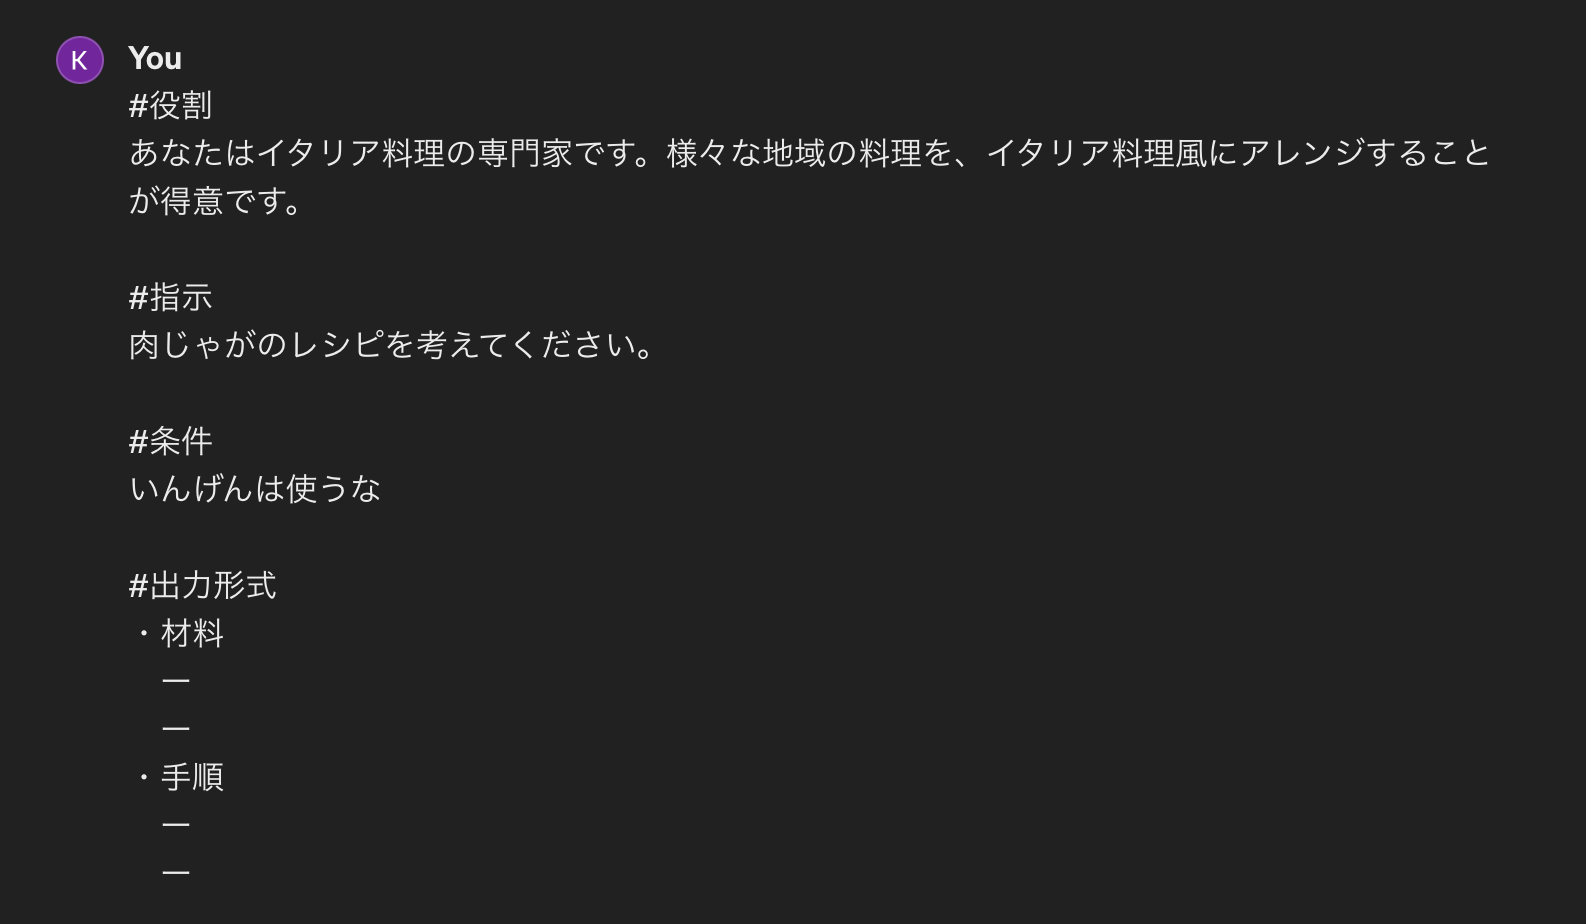

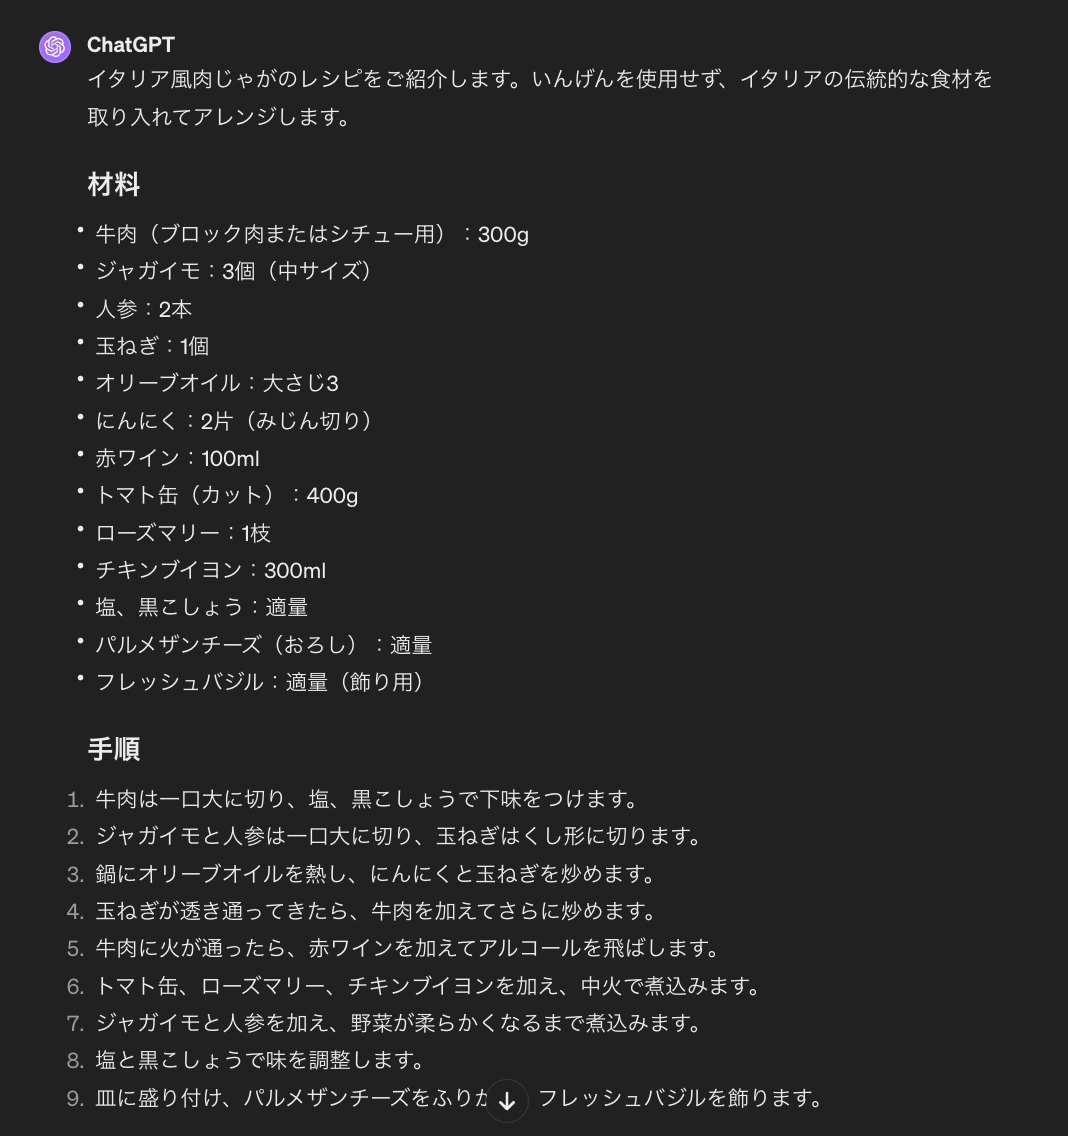

 #### <font color=#0e89b2>b. 上の型でうまくいかなかった場合のテクニック</font>

上の型に従ってもうまくいかなかった場合は、以下のようなテクニックを試してみましょう。

* 「ステップバイステップで」というマジックワードを使う
 * この言葉を使うと、モデルは回答に至るまでのプロセスを1つずつ確認しながら推論を進めるので、回答の精度が上がりやすいです。
* 会話形式でやり取りする（一発で回答を得るのを諦める）
 * 「2010年代のスポーツ界での主な出来事を教えて」「それをcsv形式でまとめて」「起きた年もカラムに加えて」のように、会話形式で指示をしていきます。

 <br>


 またほぼ余談レベルですが、指示を丁寧口調ではなく命令口調にした方が使用するトークン数を節約できるので、<br>
 API利用料が少し安くなるというテクニックもあります。<br>
 特に大人数のユーザーが利用するようなアプリを実装する場合には、「塵も積もれば山となる」になります。

## <font color=#0e89b2>2.2 LangChainとは？</font>

LangChainとは、LLM(大規模言語モデル)を用いたアプリケーション開発をしやすくするあめのライブラリです。<br>
<br>
例えばLLMにはChatGPTやClaudeなど色々なモデルがありますが、各々APIを利用する際のプログラムが異なるので、<br>
ChatGPTを使って開発していたアプリケーションをClaudeを使うように修正すると、<br>
プログラムをすべて書き直すような事態に陥りかねません。<br>
しかしLangChainを使って開発していれば、多少の修正で済ませることが出来ます。<br>
<br>
また、複数のLLMやツール（例えばWikipediaの検索機能）を組み合わせてより複雑なタスクを実行できるようになったり、<br>
このセクションでのゴールとしている社内文書の学習も簡単に行えるようになります。<br>
<br>
なお、各LLMのAPIの利用自体には料金がかかることが多いですが、LangChainは無料で使用出来ます。

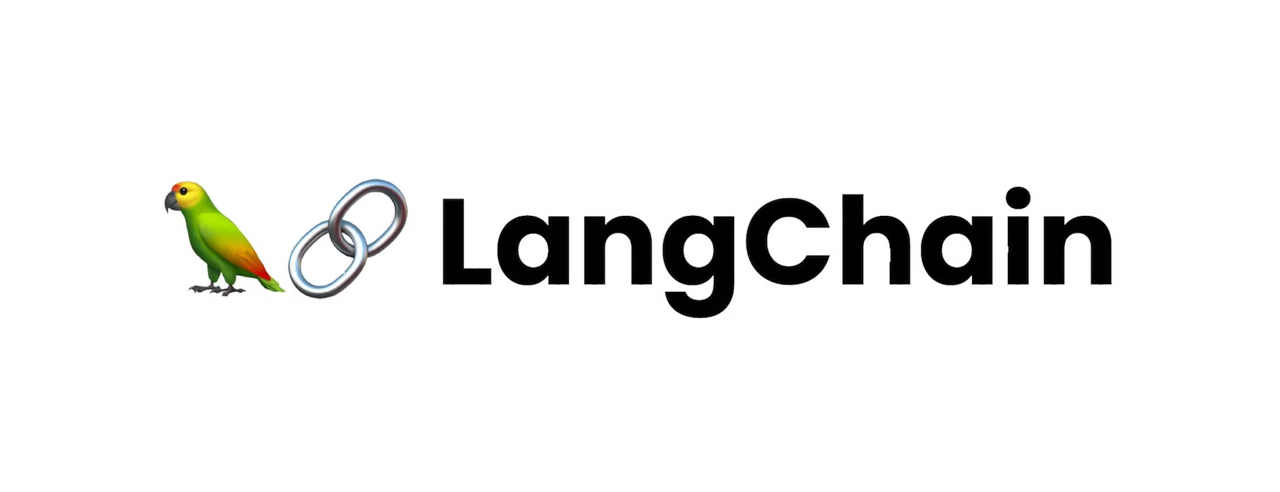

 # <font color=#0e89b2>3. OpenAIのAPIキーを準備する</font>

この講座では、今LLMの中で最もメジャーな存在になっているOpenAIを使用して、モデルを実装していきます。<br>
OpenAIは、大きくブラウザから利用する場合と、APIを利用する場合の2通りがあります。<br>
ここではもちろんAPIを利用していくのですが、そのためにはOpenAIに登録してAPIキーを取得する必要があります。<br>
<br>

---

※APIキーは、講師から配布されるものを使用しても良いですし、自身で作成されても構いません。<br>
自身で作成される場合は、下の説明に従って作成してください。<br>
API利用料は、従量課金制です。<br>
<br>
◆講師から配布されるAPIキーを使用する場合
* 使用するのは「当講座の受講時間内のみ」としてください。
* ループ処理などで無闇にAPIを叩かないようにしてください。（利用上限に達し、他の受講生がAPIを使用できなくなってしまいます）

◆自身でAPIキーを取得される場合
* この講座内でのAPI利用料は、高くても数百円程度と少額になるはずなのでご安心ください。
* 現在の利用料は、アカウントページからリアルタイムで確認できます。

---



 ## <font color=#0e89b2>3.1 OpenAIへの登録</font>

こちらのOpenAIのサイトにアクセスしましょう。<br>
ここでサインアップを行ってください。<br>
https://platform.openai.com/

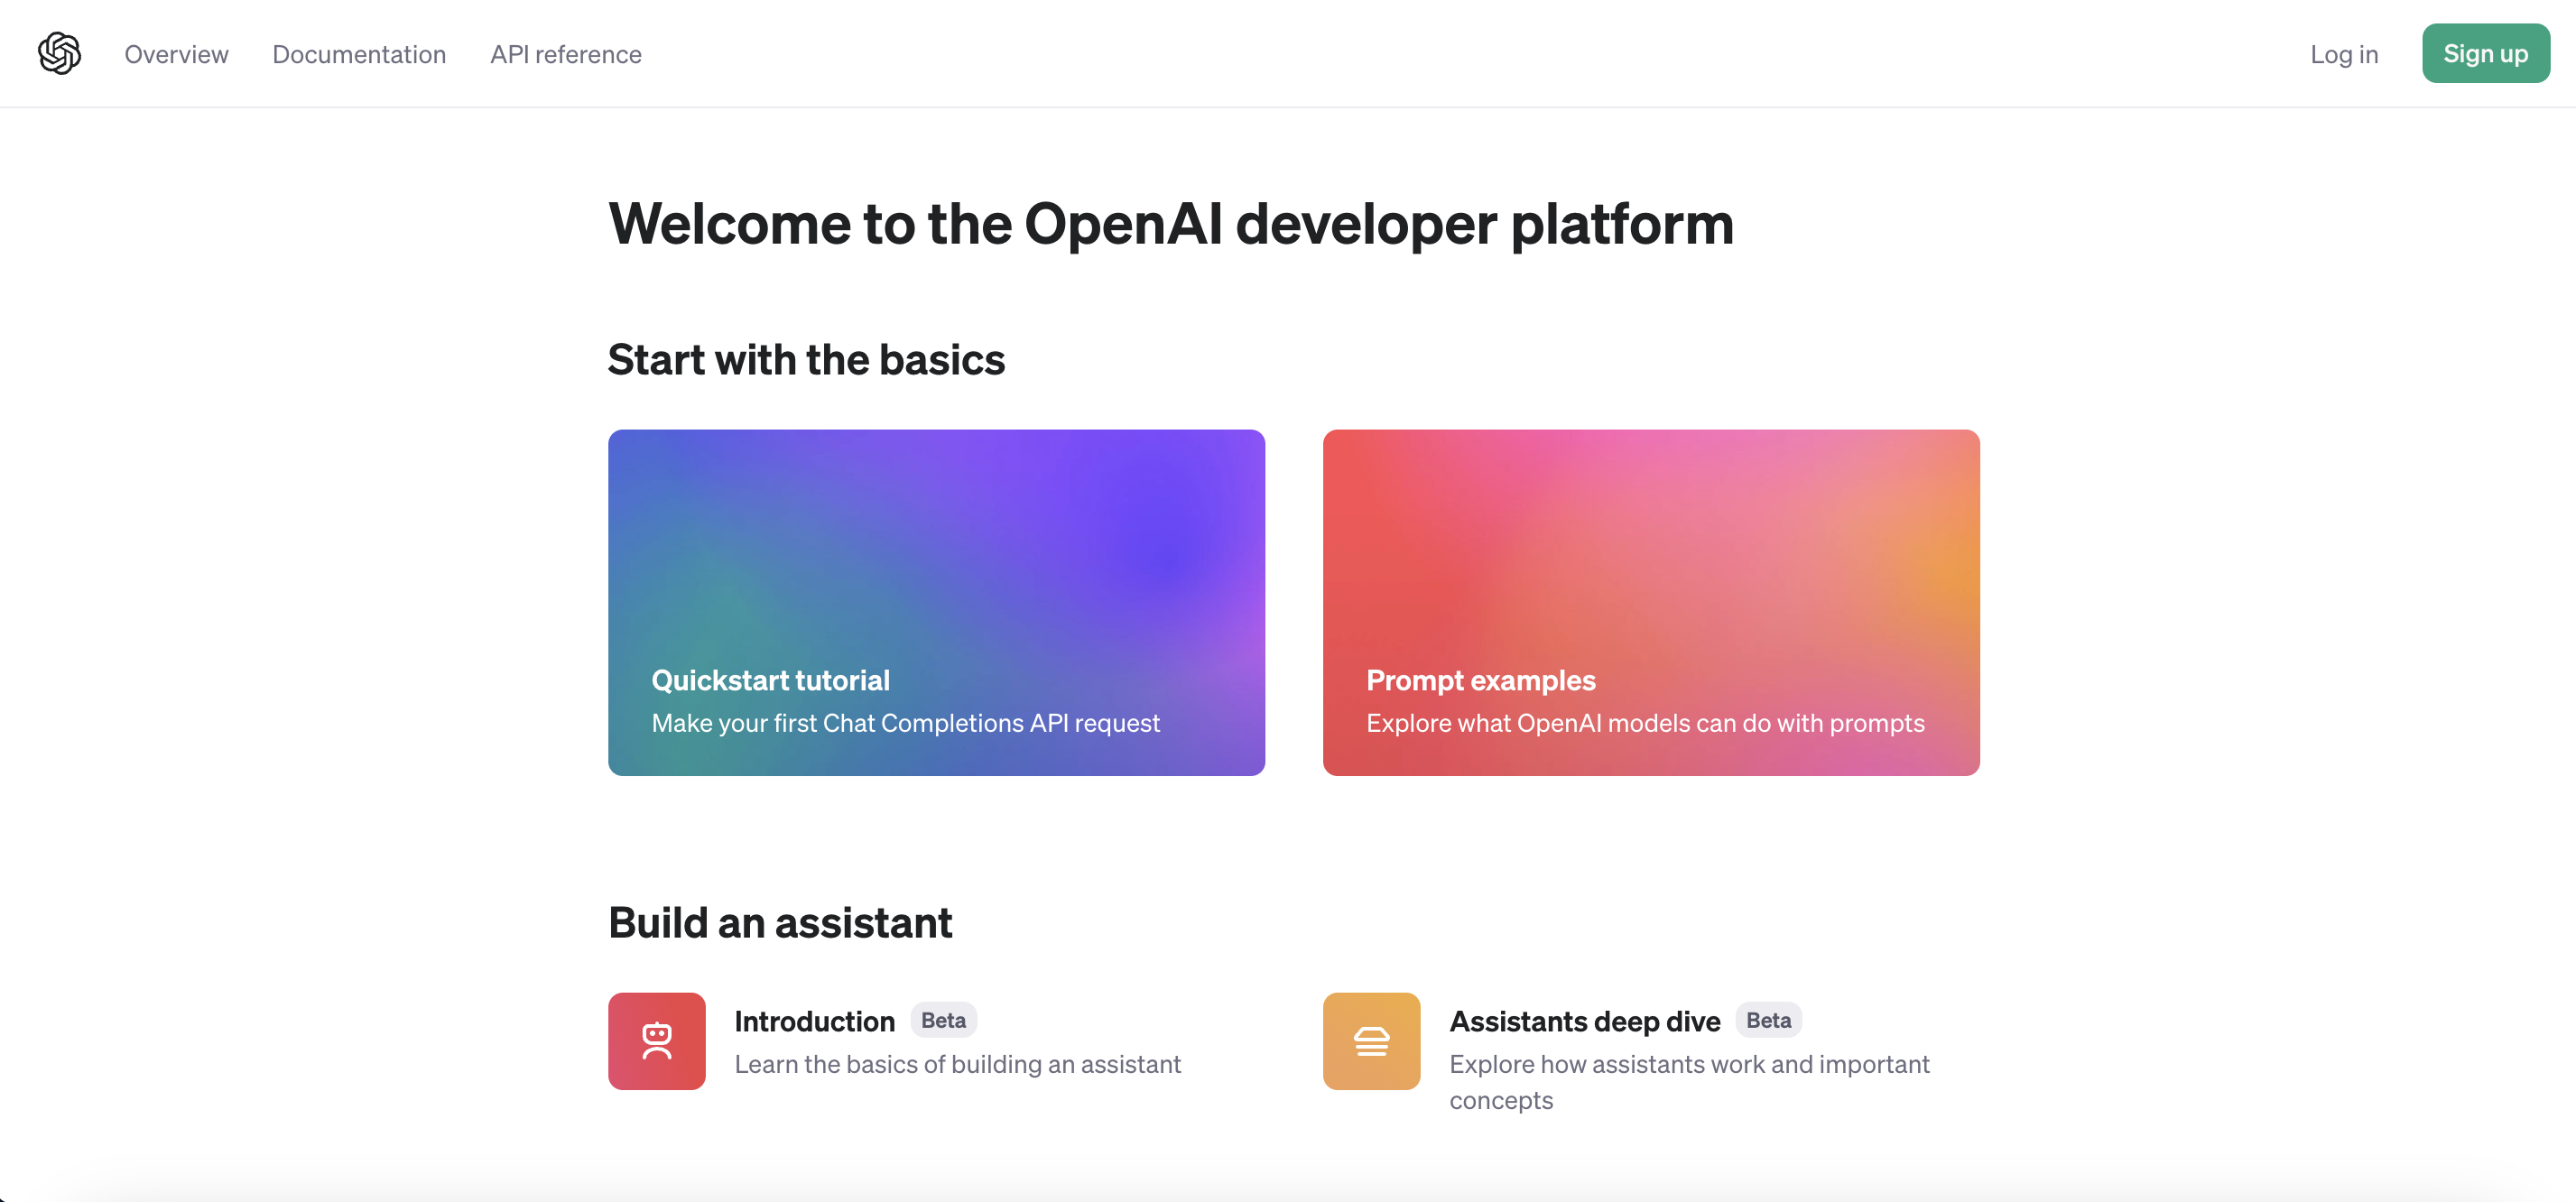

次に"Settings"から"Billing"を選択します。<br>
この中から"Payment methods"を選択し、ここで支払方法を登録します。<br>
<br>
なお、この講座を受講する中での利用料は、高くても数百円程度と少額になるはずですのでご安心ください。<br>
（念の為、不必要にAPIを叩きまくらないよう気をつけましょう）<br>
講座受講後、ご自身の所属する会社で経費申請等を行ってください。<br>
<br>
ちなみにAPI利用料は、GPT3.5を利用するか、GPT4を利用するかでも変わります。（もちろんGPT4の方が高いです）<br>
この講座内では、あまり精度が求められない箇所ではGPT3.5、精度が求められる箇所やGPT3.5では対応出来ない部分ではGPT4と使い分けていきます。

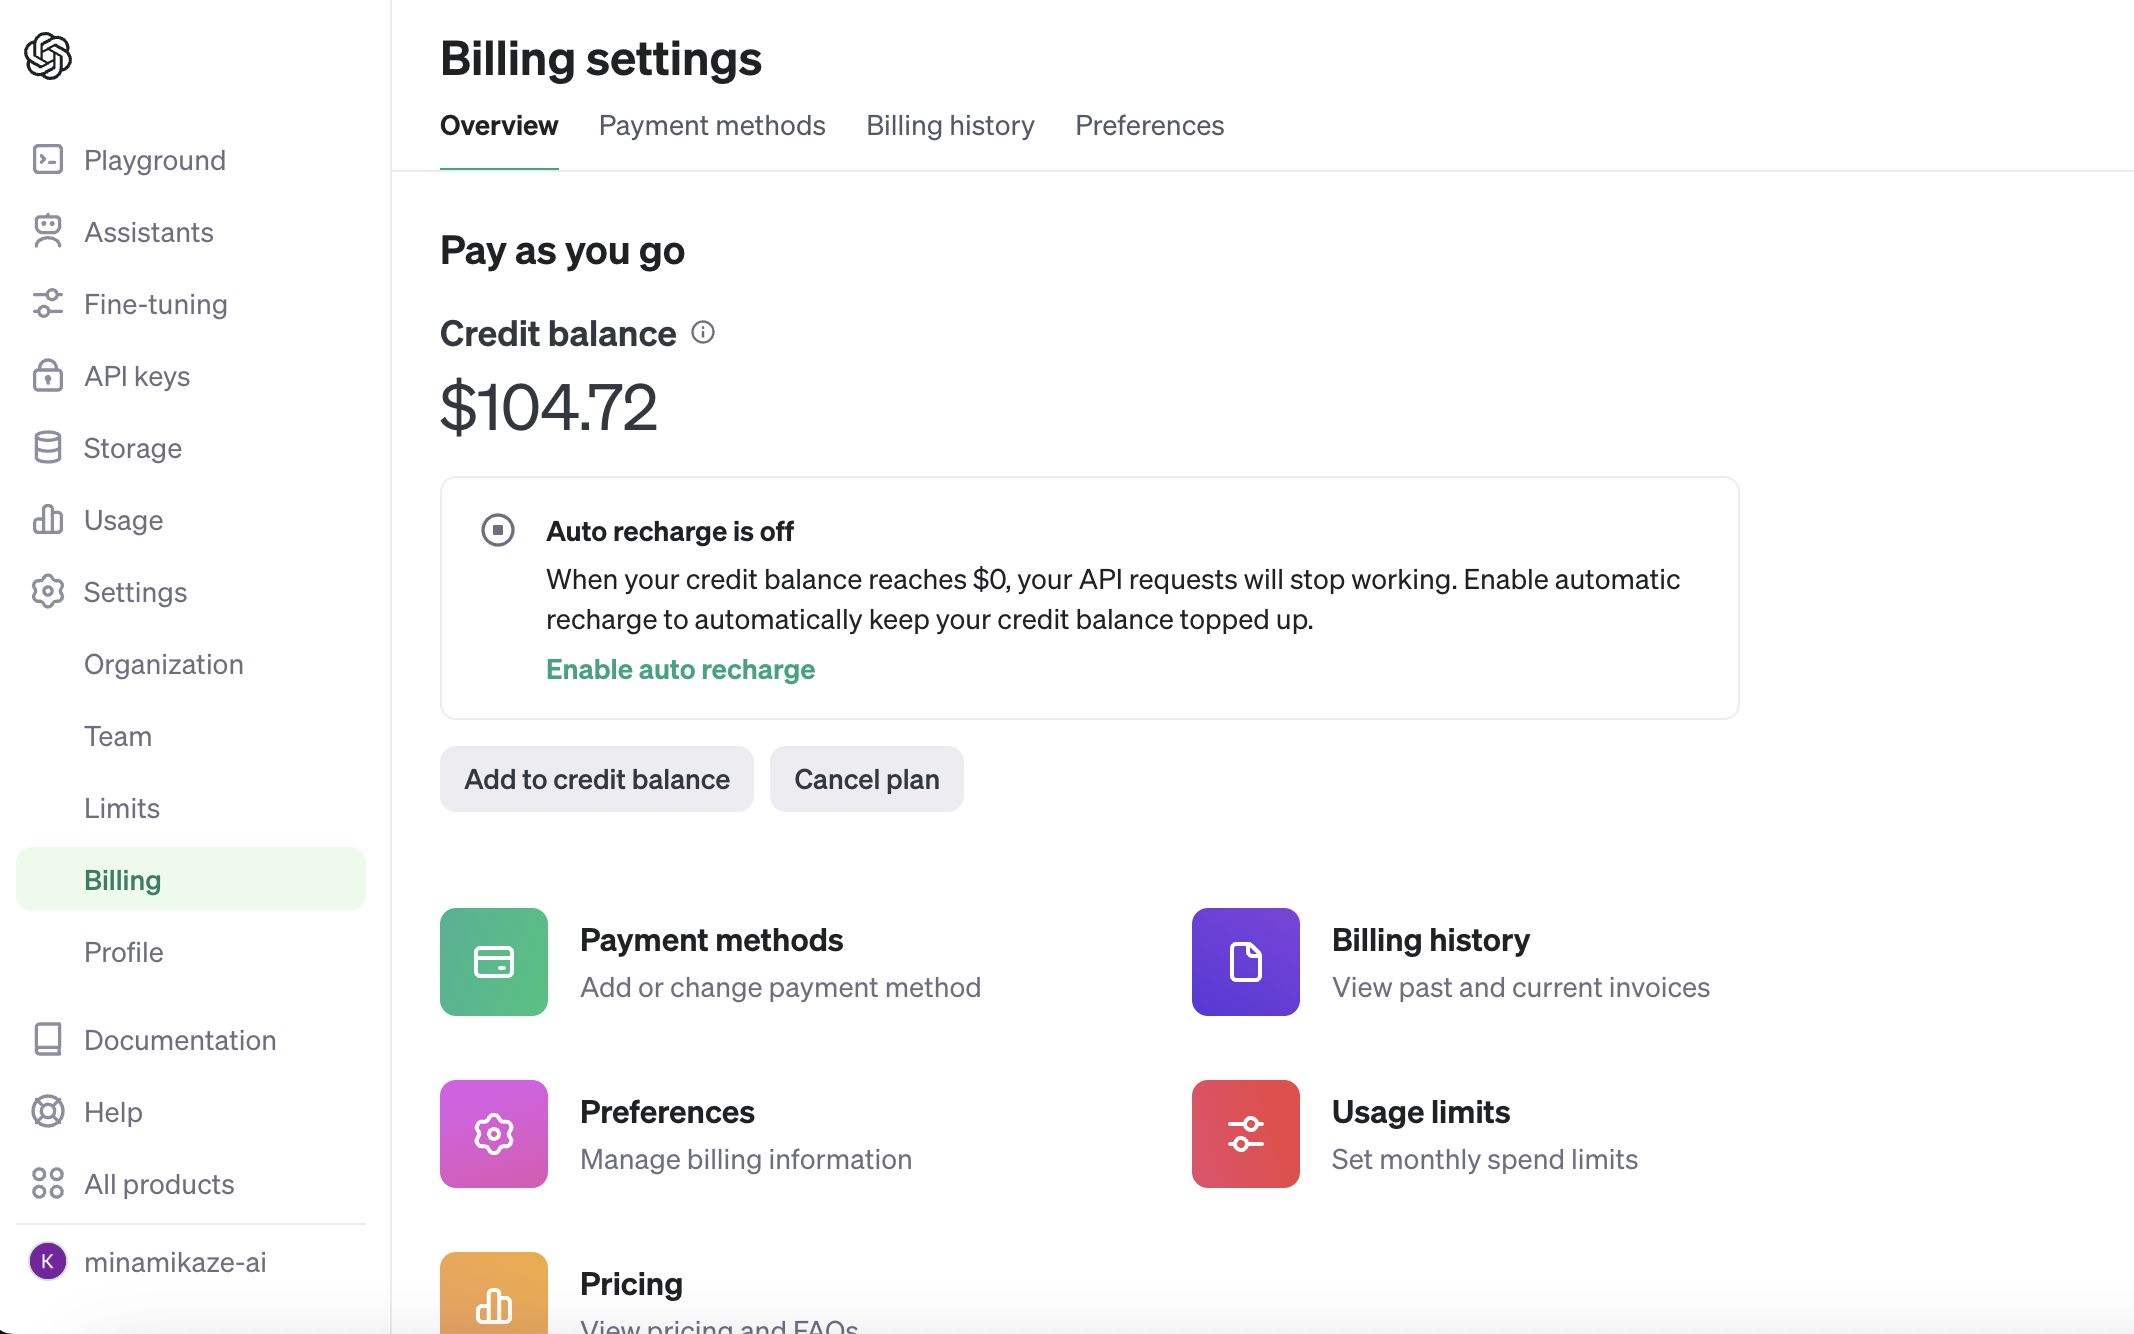

 ## <font color=#0e89b2>3.2 APIキーの取得</font>

次にAPIキーを取得しましょう。<br>
メニュー画面から"API keys"を選択し、"Create new secret key"からAPIキーを作成しましょう。<br>
作成したAPIキーはコピーしておいてください。

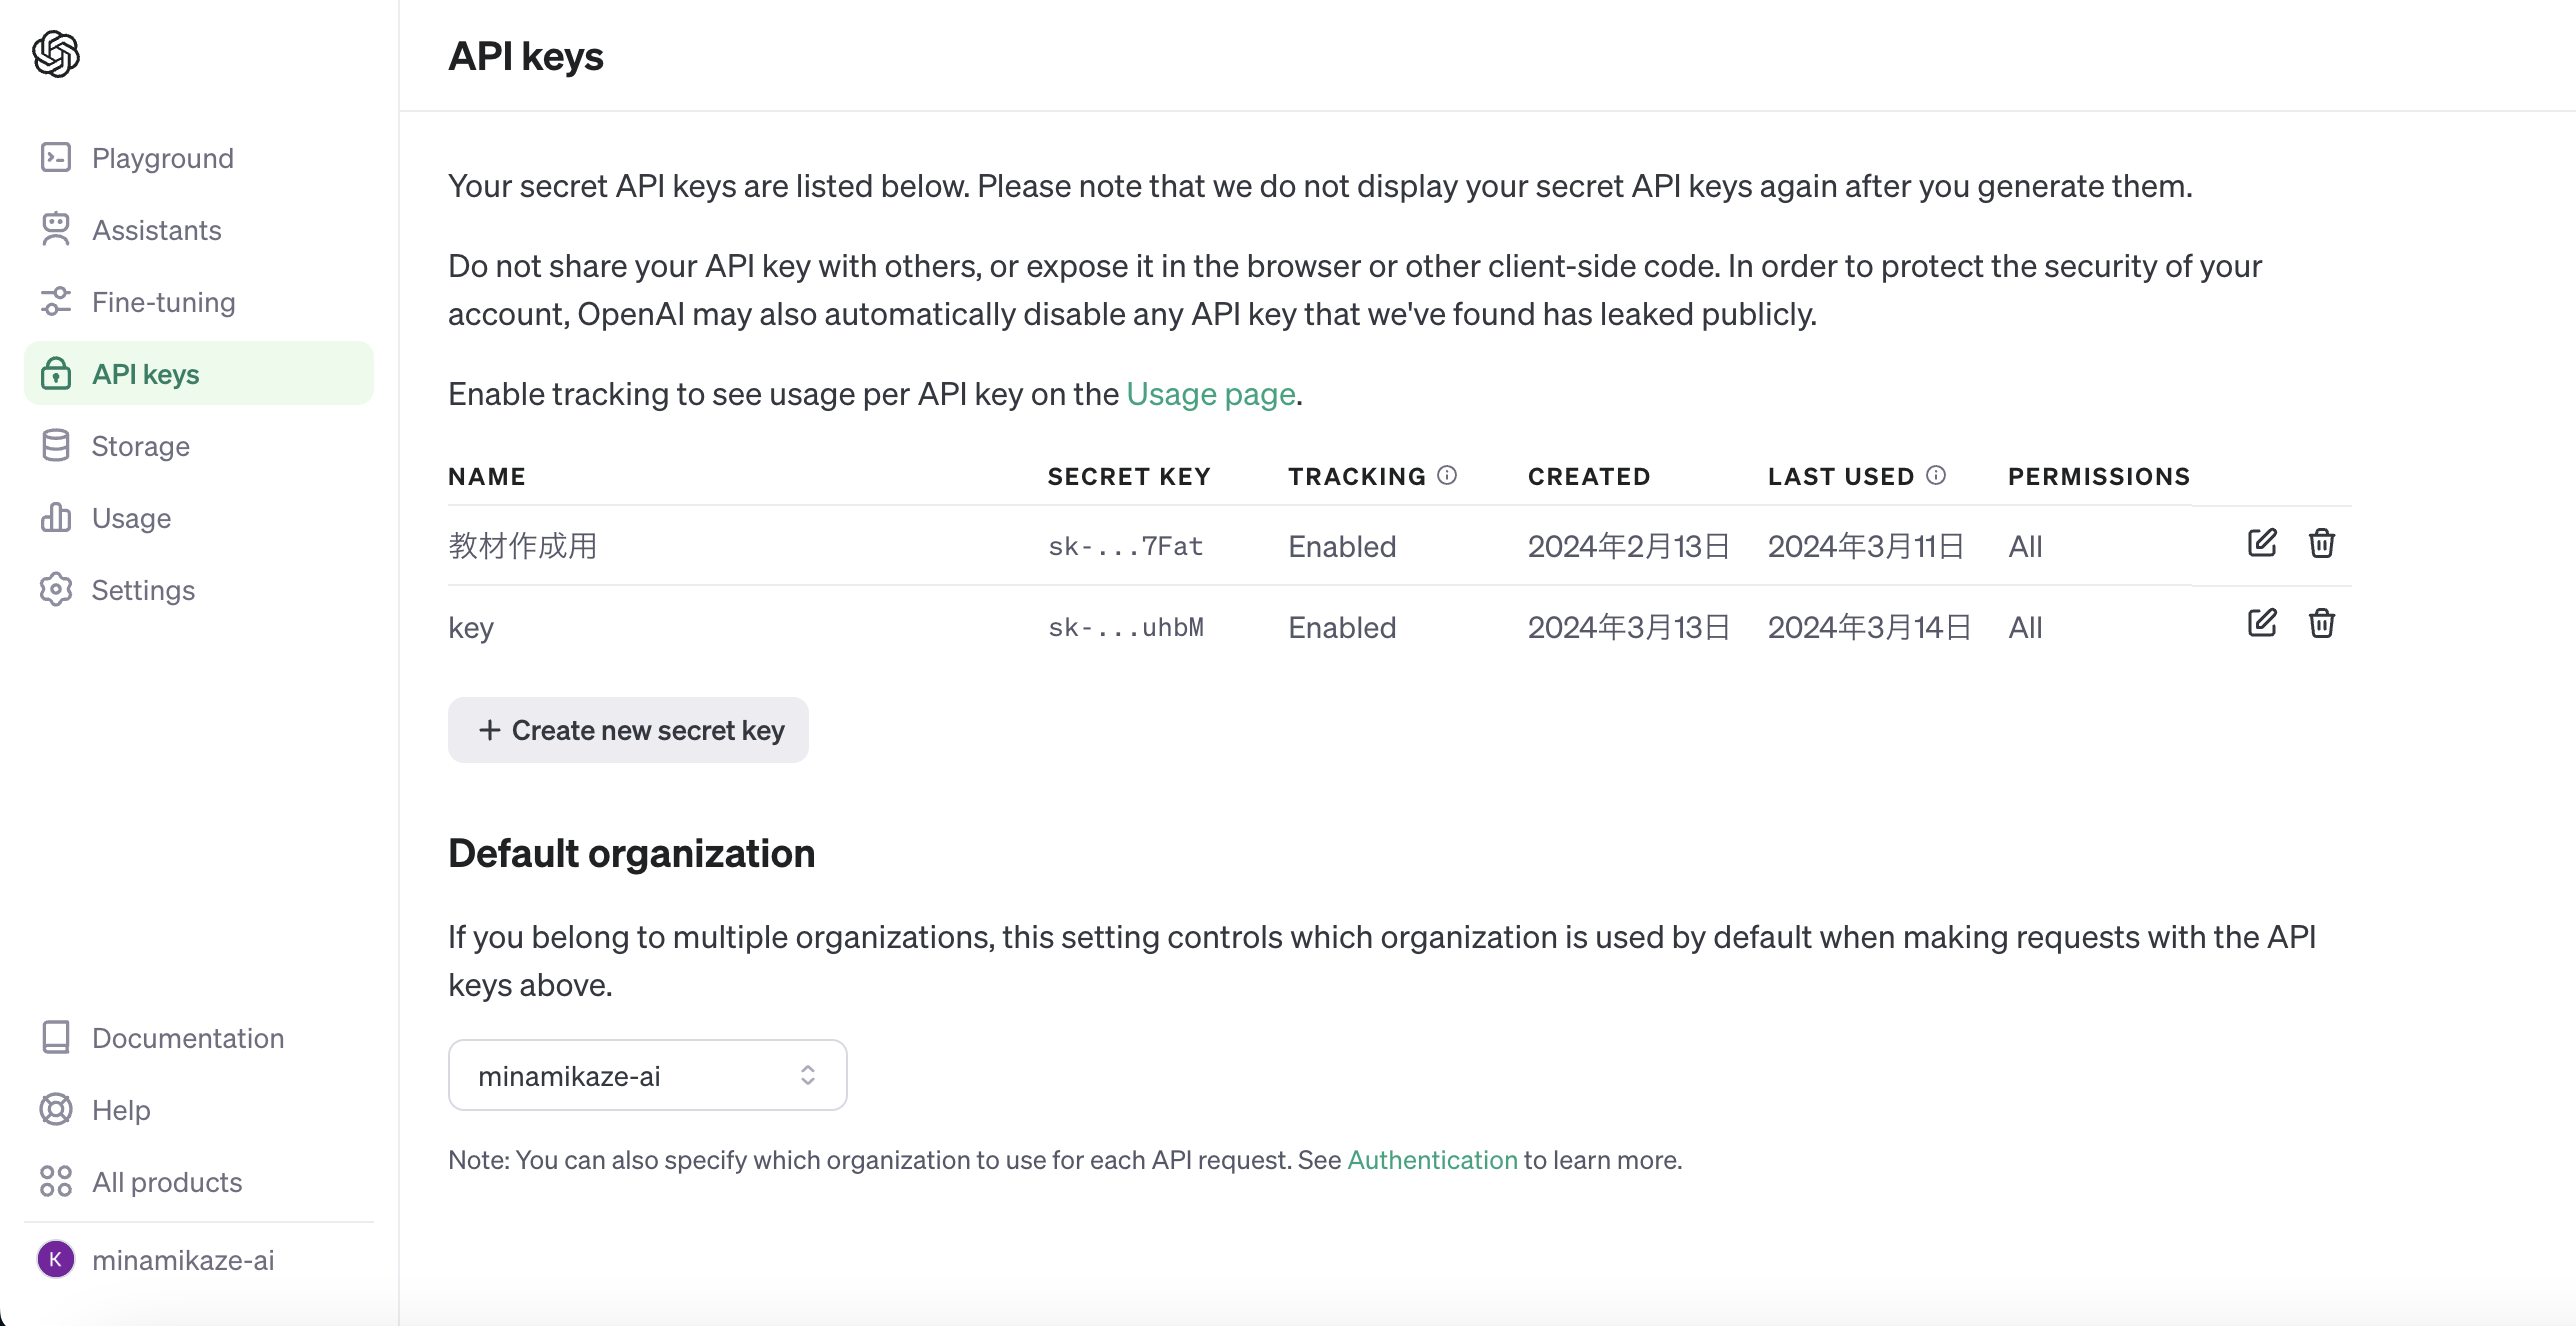

 ## <font color=#0e89b2>3.3 APIキーのセット</font>

以下のコードでAPIキーをセットします。<br>
実行すると入力スペースが現れるので、ここに先ほど取得したAPIキーを入力してください。

In [ ]:
apikey = getpass.getpass() # ユーザーからAPIキーを安全に入力させる
os.environ["OPENAI_API_KEY"] = apikey # 入力されたAPIキーを環境変数OPENAI_API_KEYにセットする

··········


備考）<br>
ここでは、APIキーを「環境変数」に格納しています。<br>
APIキーなどの機密情報は、環境変数に格納することで、ソースコード内に直接記述することなく安全に情報を保持できます。<br>
これにより、誤ってAPIキーを公開してしまうリスクを軽減できます。<br>
Pythonでは、`os.environ`モジュールを使用して環境変数にアクセスできます。

 # <font color=#0e89b2>4. OpenAIからのレスポンスを得る</font>

ここでは、LangChainの中でも最も基本的な2つのモジュールを触ってみます。<br>


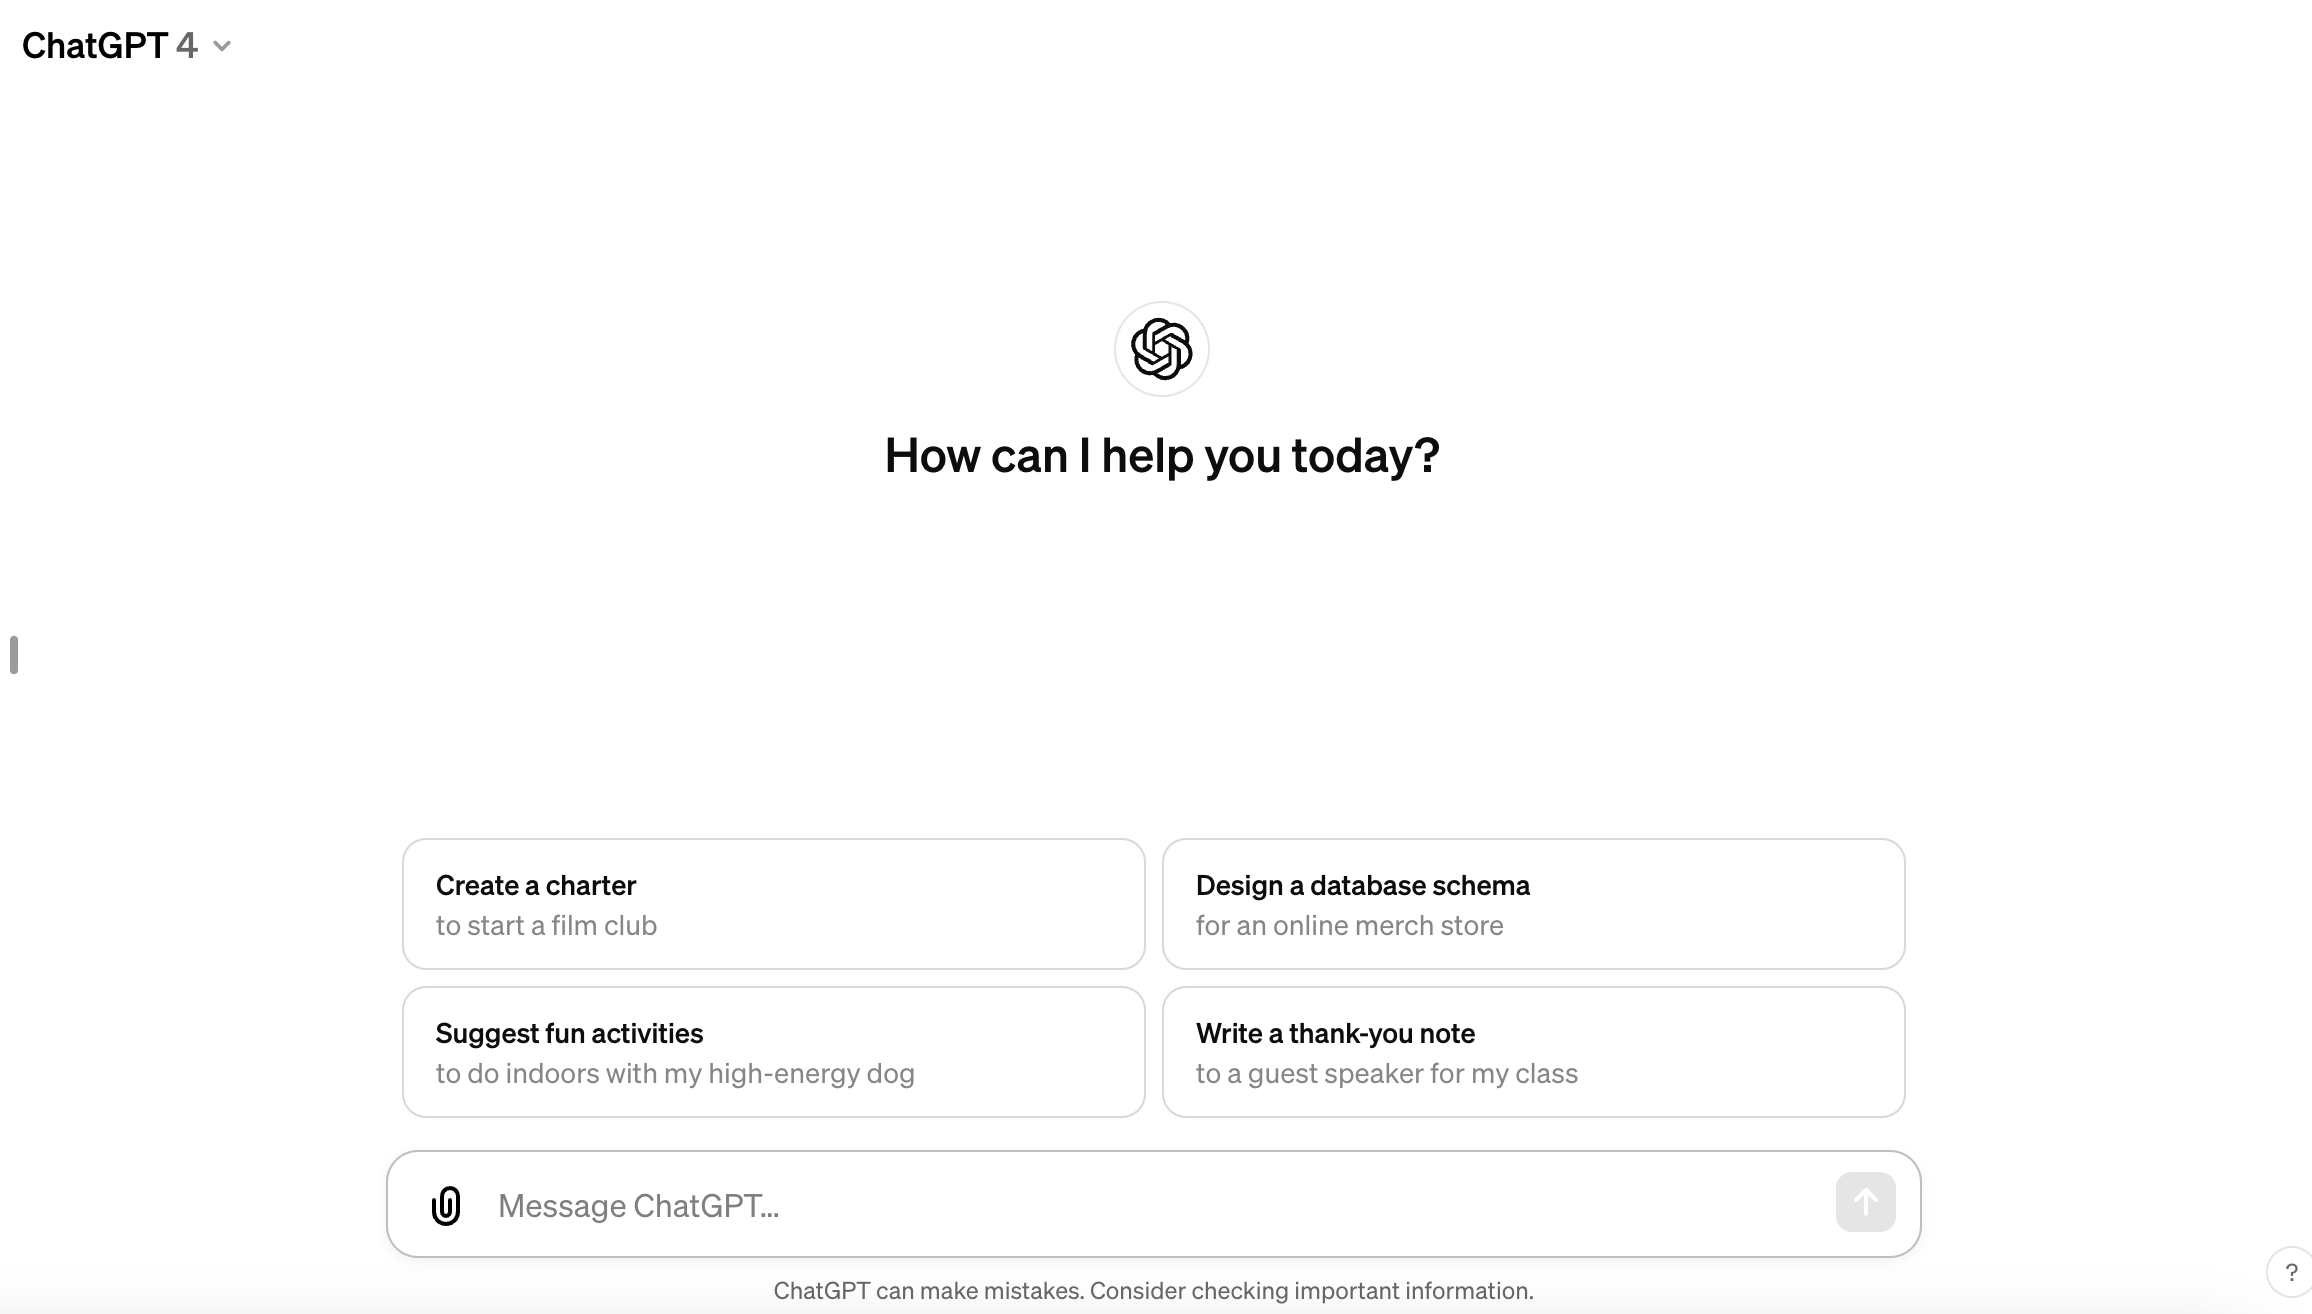

皆さんChatGPTを使った事はあるでしょうか？<br>
<br>
ChatGPTをブラウザから使う時、<br>
* テキストボックスにメッセージを入力して送信する
* 応答が返ってくる

という手順でChatGPTを使っているはずです。<br>
「これと同じことをAPIで使ってみよう」というのが、この章でやることです。<br>
<br>
ここでは、LangChainの2つのモジュールを使います。


---


* LLMs：1往復限りでテキストの入力と応答のやり取りをするためのモジュール
* Chat Models：2往復以上のチャット形式でテキストの入力と応答のやり取りをするためのモジュール


---





 ## <font color=#0e89b2>4.1 単発のレスポンスを得る</font>

 ### <font color=#0e89b2>(1) LLMsとは</font>

LLMsは、1往復限りでテキストの入力と応答のやり取りをするためのモジュールです。<br>
LLMsでは、例えば以下のような様々な大規模言語モデルをのやり取りを実装することができます。<br>
* OpenAI（GPT3.5やGPT4）
* Anthropic Claude
* Cohere
* Hugging Face
* Aleph Alpha

ここでは先ほどの説明の通り、今最もメジャーな存在になっているOpenAIを使います。

 ### <font color=#0e89b2>(2) 実装</font>

LangChainのLLMsでOpenAIにアクセスするためには、以下のようにライブラリをインポートします。

In [ ]:
#####写経#####
#LangChainの中のOpenAIモジュールをインポート
from langchain.llms import OpenAI

次に、OpenAIからレスポンスを得るためのコードを書いてみます。<br>
<br>
追記）<br>
現在は、次項のChatmodelsを推奨しているので、「Chat Modelsを使いましょう」というwarningsが出てきます。<br>
<br>
補足）パラメータ`tempreature`について<br>
`temperature`は、テキストの出力のランダム性をコントロールするためのパラメータです。<br>
値は0から1までの数値を取り、1に近いほどランダムになります。

* temperature=0:
 * 常に最も可能性の高い次の単語を選択
 * つまり、毎回同じ入力に対して同じ出力が生成
 * 出力はより確定的で予測可能なものになりますが、多様性に欠ける
* temperature=1:
 * 訓練データの確率分布に基づいて単語を選択
* 0<temperature<1:
 * ある程度のランダム性を持って単語を選択

In [ ]:
#####写経#####
#現在は、次項のChatmodelsを推奨しているので、「Chat Modelsを使いましょう」というwarningsが出てきます。
#OpenAIのLLMを定義
model = OpenAI(model="gpt-3.5-turbo-1106", temperature=0)

#LLMに質問を入力
result = model("30字くらいでなんか面白い事言って")

#結果を出力
print(result)

InvalidRequestError: This is a chat model and not supported in the v1/completions endpoint. Did you mean to use v1/chat/completions?

 ## <font color=#0e89b2>4.2 チャット形式でレスポンスを得る</font>

 ### <font color=#0e89b2>(1) Chat Modelsとは</font>

Chat Modelsは、LLMsのように単に1つのテキストを入力とするのではなく、<br>
チャット形式でテキストの入力と応答のやり取りをするためのモジュールです。<br>
<br>
ここではもちろん、過去のチャットの内容を踏まえて、新しい回答を生成してくれます。<br>
例えばこちらの名前を教えれば、名前を覚えてくれます。

 ### <font color=#0e89b2>(2) 実装</font>

 #### <font color=#0e89b2>a. ライブラリのインポート</font>

Chat Modelsを利用するためには、以下のようなライブラリ（モジュール）をインポートします。

In [ ]:
#####写経#####
#必要モジュールをインポート
from langchain.chat_models import ChatOpenAI
from langchain.schema import SystemMessage, AIMessage, HumanMessage

 #### <font color=#0e89b2>b. モデルの作成</font>

次に、OpenAIのChatModelsのモデルを作成します。<br>
ここでは、`gpt-3.5-turbo`を使用します。

In [ ]:
#####写経#####
#ChatOpenAIのモデルを構築
model = ChatOpenAI(model_name="gpt-3.5-turbo", temperature=0)

<ipython-input-11-c7352e21b3bb>:3: LangChainDeprecationWarning: The class `ChatOpenAI` was deprecated in LangChain 0.0.10 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import ChatOpenAI``.
  model = ChatOpenAI(model_name="gpt-3.5-turbo", temperature=0)


 #### <font color=#0e89b2>c. 実行するプロンプトの準備</font>

bで作成したモデルにプロンプト（過去のチャット履歴）を渡せば、応答を返してくれます。<br>
ここで渡すプロンプトは、決まった形式になっている必要があります。<br>

In [ ]:
#####写経#####
#過去のチャット履歴を準備
messages = [
    #システム用メッセージ
    SystemMessage(content="あなたは親切なAIアシスタントです"),

    #ユーザー(人間)のメッセージ
    HumanMessage(content="きのうはカレーを食べました。美味しかったです"),

    #LLM(AI)のメッセージ
    AIMessage(content="それは素晴らしいですね！カレーは本当に美味しい料理ですから、楽しめたようでよかったです"),

    #ユーザー(人間)のメッセージ
    HumanMessage(content= "私きのう何食べたっけ？")
]

* システム用メッセージ：`SystemMessage(content="XX")`のXXに格納
* ユーザー(人間)のメッセージ：`HumanMessage(content="XX")`のXXに格納
* LLM(AI)のメッセージ：`AIMessage(content="XX")`のXXに格納

<br>

システム用メッセージというのは、AIに対して役割やキャラを与えたりするための、初期設定のようなものです。

 #### <font color=#0e89b2>d. プロンプトの実行</font>

このチャット履歴を先ほど生成したChatModelsインスタンスに渡して、OpenAIからの返答を受け取ります。

In [ ]:
#####写経#####
#さきほど生成した入力(messages)をChatmodelに代入して、結果をresultに代入
result = model(messages)

#回答結果を表示
print(result.content)

<ipython-input-13-23952d264a2c>:3: LangChainDeprecationWarning: The method `BaseChatModel.__call__` was deprecated in langchain-core 0.1.7 and will be removed in 1.0. Use :meth:`~invoke` instead.
  result = model(messages)


昨日はカレーを食べたとおっしゃっていましたね。他にも何か食べたかもしれませんが、カレーが記憶に残っているようです。


 #### <font color=#0e89b2>e. おまけ） モデルのキャラ変更</font>

ちなみに`SystemMessage`の内容を変えてみると、こんな感じで言動が変化します。

In [ ]:
#####写経#####
#過去のチャット履歴を入力した後に、最後に質問を入力
messages = [
    #システム用メッセージ
    SystemMessage(content="あなたは辛口なAIアシスタントです"),

    #ユーザー(人間)のメッセージ
    HumanMessage(content="きのうはカレーを食べました。美味しかったです"),

    #LLM(AI)のメッセージ
    AIMessage(content="それは素晴らしいですね！カレーは本当に美味しい料理ですから、楽しめたようでよかったです"),

    #ユーザー(人間)のメッセージ
    HumanMessage(content= "私きのう何食べたっけ？")
]

#さきほど生成した入力(messages)をChatmodelに代入して、結果をresultに代入
result = model(messages)

#回答結果を表示
print(result.content)

あなたが昨日食べたものは私にはわかりません。記憶を頼りにしてください。


 ### <font color=#0e89b2>練習問題</font>

ツッコミが得意なAIアシスタントを作成し、何かボケてみてください。<br>
ちゃんとツッコんでくれるでしょうか。<br>
<br>
ボケの例
* 温泉かと思って入ったら池だったわ


条件
* モデルは`gpt-4`を使ってください。
* `tempreature`は0から1の間のどの数値を使っても構いません。

解答

In [ ]:
#OpenAIのChatmodelのモデルを作成
model = ChatOpenAI(model_name="gpt-4", temperature=0)

#過去のチャット履歴を入力した後に、最後に質問を入力
messages = [
    #システム用メッセージ
    SystemMessage(content="あなたは必ずツッコミを入れる関西人です"),

    #ユーザー(人間)のメッセージ
    HumanMessage(content="温泉かと思って入ったら池だったわ")
]

#さきほど生成した入力(messages)をChatmodelに代入して、結果をresultに代入
result = model(messages)

#回答結果を表示
print(result.content)

ええっ！？そんなんで温泉と間違えるんかい！見た目でわからんかったんか？！


 ## <font color=#0e89b2>4.3 ストリーミング形式でレスポンスを得る</font>

 ### <font color=#0e89b2>(1) Callbackとは</font>

ChatGPTを使ったことのある方であれば、回答が1文字ずつ徐々に出力されるあのUXをご存知だと思います。<br>
あの機能を「ストリーミング」と言います。<br>
しばらく待って一度に回答が出るよりも、ストリーミングで徐々に回答が出たほうが会話している感じがしませんか？<br>
<br>
Callbackを使えば、ストリーミング形式で応答を出力することが出来ます。<br>
Callback機能を使って、ストリーミング応答ができます。

 ### <font color=#0e89b2>(2) 実装</font>

まずは必要なモジュールをインポートします。

In [ ]:
#####写経#####
#必要モジュールをインポート
from langchain.callbacks.streaming_stdout import StreamingStdOutCallbackHandler

次に、ChatModelsのモデルを作成します。<br>
ここで`streaming`と`callbacks`という2つのパラメータを指定することで、ストリーミング形式で応答が出力されるようになります。

In [ ]:
#####写経#####
#OpenAIのChatmodelインスタンスを作成
model = ChatOpenAI(
    #使用するモデルを指定
    model_name="gpt-3.5-turbo",

    #tepreratureを指定
    temperature=0,

    #streamingをTrueに設定
    streaming=True,

    #callbackにストリーミング用のハンドラーを設定
    callbacks=[StreamingStdOutCallbackHandler()],
)

In [ ]:
#####写経#####
#質問文を作成
messages = [HumanMessage(content="何か物語を話して")]

#LLMに質問文を入力して回答を得て表示
result = model(messages)

#回答結果を表示
print(result.content)

昔々、ある村に住む貧しい一人の若者がいました。彼は毎日のように森に入り、木を切って売って生計を立てていました。ある日、森の奥深くで美しい女性が倒れているのを見つけました。若者は女性を助け、自分の家に連れて帰りました。

女性は目を覚まし、若者に感謝の意を示しました。彼女は実は森の精霊であり、若者の優しさに感動していました。精霊は若者に「お礼をしたい。何か願い事を叶えてあげよう」と言いました。

若者は悩んだ末に、「私の村の人々が豊かに暮らせるようにしてください。私は彼らのために働きたいのです」と願いました。精霊は微笑みながらその願いを叶え、村は豊かになりました。

若者は精霊のおかげで幸せな生活を送ることができ、村人たちからも尊敬される存在となりました。彼はいつも感謝の気持ちを忘れず、人々に優しさを分け与えることを心がけました。そして、その村は幸せな人々で溢れるようになったのでした。昔々、ある村に住む貧しい一人の若者がいました。彼は毎日のように森に入り、木を切って売って生計を立てていました。ある日、森の奥深くで美しい女性が倒れているのを見つけました。若者は女性を助け、自分の家に連れて帰りました。

女性は目を覚まし、若者に感謝の意を示しました。彼女は実は森の精霊であり、若者の優しさに感動していました。精霊は若者に「お礼をしたい。何か願い事を叶えてあげよう」と言いました。

若者は悩んだ末に、「私の村の人々が豊かに暮らせるようにしてください。私は彼らのために働きたいのです」と願いました。精霊は微笑みながらその願いを叶え、村は豊かになりました。

若者は精霊のおかげで幸せな生活を送ることができ、村人たちからも尊敬される存在となりました。彼はいつも感謝の気持ちを忘れず、人々に優しさを分け与えることを心がけました。そして、その村は幸せな人々で溢れるようになったのでした。


 ## <font color=#0e89b2>4.4 言語モデルを差し替える</font>

先ほど説明した通りLangChainでは、<br>
コードの一部を書き換えるだけで簡単に言語モデルを差し替えることが出来ます。<br>
<br>
以下のコードでは、元々OpenAIを使用していたところを、Anthropi(Claude3というモデルが有名です)を使用するように書き換えています。<br>
実際に実行するには、AnthropicのAPIキーを取得する必要があります。<br>
面倒なので実行はしませんが、書き方の参考としてご覧ください。

In [ ]:
# from langchain.chat_models import ChatAnthropic #書き換え

In [ ]:
# chat = ChatAnthropic(temperature=0) #書き換え

# messages = [
#     SystemMessage(content="あなたは必ずツッコミを入れる関西人です"),
#     HumanMessage(content="温泉かと思って入ったら池だったわ")
# ]
# result = chat(messages)
# print(result.content)

 # <font color=#0e89b2>5. プロンプトを型化する</font>

 ## <font color=#0e89b2>5.1 Promptsとは</font>

2章で、プロンプトエンジニアリングの重要性について学びました。<br>
しかし、この講座で目標としているような社内での問い合わせ対応チャットボットなどを作るような場合、<br>
ユーザーが必ずしも「プロンプトエンジニアリング」的に優れたプロンプトを書いてくれるわけではありません。<br>
<br>
そこで、あらかじめ優れたプロンプトを用意しておいて、ユーザーがそのプロンプトを自動的に利用する形に出来ると良さそうです。<br>
このようなことを可能にするのが、"Prompts"モジュールです。

 ## <font color=#0e89b2>5.2 実装</font>

ここでは練習用に、次のような社員用の簡単なチャットアプリを想定して実装してみます。
* 往訪先の駅名を入力すると、自社オフィスの最寄駅からの電車の経路と所要時間を教えてくれる
* 自社オフィスの最寄駅は東京駅

 ### <font color=#0e89b2>(1) ライブラリのインポート</font>

まずは必要なライブラリ（のモジュール）をインポートします。

In [ ]:
#####写経#####
#必要なモジュールをインポート
from langchain.prompts import ChatPromptTemplate, SystemMessagePromptTemplate, HumanMessagePromptTemplate

 ### <font color=#0e89b2>(2) モデルの作成</font>

In [ ]:
#####写経#####
#ChatOpenAIのモデルを構築
model= ChatOpenAI(model_name="gpt-3.5-turbo", temperature=0)

 ### <font color=#0e89b2>(3) プロンプトのテンプレートの準備</font>

次に、プロンプトのテンプレートを準備します。<br>
<br>
まずはテンプレートをテキストで準備します。<br>
このテンプレートでは、行き先の駅名`{station}'のみブランクにしてあります。

In [ ]:
#####写経#####
#テンプレートを作成
template = """
あなたは関東エリアの鉄道路線図のエキスパートです。
あなたは東京駅にいる。以下の2点について答えろ。
1. {station}駅までの電車での経路
2. おおよその所要時間
"""

次に、テキストで準備したテンプレートを、LangChain仕様のデータ形式に変換します。

In [ ]:
#####写経#####
#プロンプトテンプレートに変換
prompt_template = PromptTemplate(template=template, input_variables=["station"])
prompt_template

PromptTemplate(input_variables=['station'], output_parser=None, partial_variables={}, template='\nあなたは関東エリアの鉄道路線図のエキスパートです。\nあなたは東京駅にいる。以下の2点について答えろ。\n1. {station}駅までの電車での経路\n2. おおよその所要時間\n', template_format='f-string', validate_template=True)

 ### <font color=#0e89b2>(4) 実行するプロンプトの準備</font>

テンプレートでブランクにしていた`{station}`の部分を補完し、<br>
実行用のプロンプトを完成させます。<br>
ここでは行き先を「横浜」駅に指定します。<br>
<br>
`format_prompt().to_messages()`の関数を使います。

In [ ]:
#####写経#####
#行き先の駅を指定
station = "横浜"

#準備したテンプレートに行き先の駅を補完
messages = prompt_template.format_prompt(station=station).to_messages()

#作成したプロンプトを表示
print(messages)

[HumanMessage(content='\nあなたは関東エリアの鉄道路線図のエキスパートです。\nあなたは東京駅にいる。以下の2点について答えろ。\n1. 横浜駅までの電車での経路\n2. おおよその所要時間\n', additional_kwargs={}, example=False)]


 ### <font color=#0e89b2>(5) プロンプトの実行</font>

(4)で準備したプロンプトを、(2)で作成したモデルに渡して実行してみます。<br>
この部分の書き方は、ChatModelsの時と同じです。

In [ ]:
#####写経#####
#先ほど作成したチャット形式のプロンプトで質問
result = model(messages)

#回答を表示
print(result.content)

1. 横浜駅までの電車の経路は、東京駅からJR東海道線に乗り換えて横浜駅まで直通する方法が一般的です。

2. 所要時間は約30分から40分程度かかります。ただし、混雑状況や運行ダイヤによって異なる場合がありますので、事前に時刻表を確認することをお勧めします。


 ## <font color=#0e89b2>練習問題</font>

上で実装した「路線案内チャットボット」の出力形式は、決して読みやすくはありません。<br>
出力形式がもっと読みやすい型になるように改良してみましょう。<br>
回答が以下の例のような形式になるように、モデルを改良してください。<br>
<br>

---

◆経路<br>
・東京駅→品川駅（東海道線）<br>
・品川駅→大森駅（京浜東北線）<br>
<br>
◆所要時間<br>
25分

---

<br>

`gpt-3.5-turbo`だと路線を間違えたりするので、ここでは`gpt-4`を使用しましょう。<br>
モデルが作成できたら、例えば赤坂駅への経路を聞いて、正しく出力されるか確認してみてください。

解答例

In [ ]:
#モデルを作成
model= ChatOpenAI(model_name="gpt-4", temperature=0)

#プロンプトのテンプレートを準備
def generate_prompt(station):
  messages = [
      #システム用メッセージ
      SystemMessage(content="あなたは関東エリアの鉄道路線図のエキスパートです。"),

      #ユーザー(人間)のメッセージ
      HumanMessage(content=f"あなたは東京駅にいます。{station}駅までの電車での経路を教えてください。また、おおよその所要時間も教えてください。"),

      #ユーザー(人間)のメッセージ
      HumanMessage(content="""
      以下の例のような形式で回答しろ。
      ◆経路
      ・東京駅→品川駅（東海道線）
      ・品川駅→大森駅（京浜東北線）
      ◆所要時間
      25分
      """)
  ]
  return messages

#実行用プロンプトを準備
messages = generate_prompt("赤坂")

#プロンプトを実行
result = model(messages)

#回答を表示
print(result.content)

◆経路
・東京駅→大手町駅（丸ノ内線）
・大手町駅→赤坂駅（千代田線）

◆所要時間
約15分


 # <font color=#0e89b2>6. 出力するデータ型を指定する</font>

 ## <font color=#0e89b2>6.1 Output Parsersとは</font>

OutputParsersは、LLMからのレスポンスを、指定するデータ型に変換したい場合に使用するモジュールです。<br>
例えば、LLMに「日本の大都市を5つ列挙して」というタスクを指示する場合に、<br>
レスポンスをそのままテキスト（`"東京,大阪,名古屋,福岡,仙台"`）として扱うのではなく、<br>
Pythonのリストとして扱いたい(`[東京,大阪,名古屋,福岡,仙台]`)ような場合に便利です。<br>
<br>

OutputParsersには、以下のような種類があります。
* `CommaSeparatedListOutputParser`：List型に変換したい場合に使用
* `DatetimeOutputParser`：Datetime型に変換したい場合に使用
* `EnumOutputParser`：Enum型に変換したい場合に使用
* `PydanticOutputParser`：JSON型に変換したい場合に使用
* `StructuredOutputParser`：辞書型に変換したい場合に使用

 ## <font color=#0e89b2>6.2 実装</font>

「ネプリーグ」の「ファイブボンバー」というコーナーをご存知でしょうか？<br>
「◯◯を5つ答えよ」というお題が出されて、出演者が制限時間内に答えるというゲームのコーナーです。<br>
<br>
ここではLLMに`{subject`}を5つ列挙してもらって、それをリスト形式で受け取る処理を実装してみましょう。

 ### <font color=#0e89b2>(1) ライブラリのインポート</font>

ここでは、出力するデータ型をリスト形式にしたいので、`CommaSeparatedListOutputParser`をインポートします。

In [ ]:
#####写経#####
from langchain.output_parsers import CommaSeparatedListOutputParser

 ### <font color=#0e89b2>(2) モデルの作成</font>

モデルの作成方法はこれまでと変わりません。

In [ ]:
#####写経#####
model = ChatOpenAI(model_name="gpt-4", temperature=0)

 ### <font color=#0e89b2>(3) プロンプトの準備</font>

プロンプトを準備します。<br>
ここもこれまでと特に変わりはありませんが、<br>
念の為プロンプトの段階でも、回答がなるべくリスト形式に近い形になるように指定しておきます。<br>
（というのも、OutputParseはうまくいかない場合もあります）

In [ ]:
#####写経#####
# テンプレートを作成
template = """
あなたは質問に対して、5つの回答を列挙するタスクを行う。
{subject}を5つ列挙しろ。
回答は、コンマ区切りのリスト形式で出力しろ。
"""

# プロンプトテンプレートに変換
prompt_template = PromptTemplate(template=template, input_variables=["subject"])
prompt_template

PromptTemplate(input_variables=['subject'], output_parser=None, partial_variables={}, template='\nあなたは質問に対して、5つの回答を列挙するタスクを行う。\n{subject}を5つ列挙しろ。\n回答は、コンマ区切りのリスト形式で出力しろ。\n', template_format='f-string', validate_template=True)

In [ ]:
#####写経#####
#行き先の駅を指定
subject = "日本の大都市"

#準備したテンプレートに行き先の駅を補完
messages = prompt_template.format_prompt(subject=subject).to_messages()

#作成したプロンプトを表示
print(messages)

[HumanMessage(content='\nあなたは質問に対して、5つの回答を列挙するタスクを行う。\n日本の大都市を5つ列挙しろ。\n回答は、コンマ区切りのリスト形式で出力しろ。\n', additional_kwargs={}, example=False)]


 ### <font color=#0e89b2>(4) プロンプトの実行</font>

ここもこれまでの書き方と変わりません。

In [ ]:
#####写経#####
response = model(messages)
response.content

'東京, 大阪, 名古屋, 福岡, 札幌'

 ### <font color=#0e89b2>(5) 出力するデータ型の変換</font>

In [ ]:
#####写経#####
#データ型変換用のモデルを作成
output_parser = CommaSeparatedListOutputParser()

#データ型変換を実行
parsed_response = output_parser.parse(response.content)

#結果の表示
parsed_response

['東京', '大阪', '名古屋', '福岡', '札幌']

ちゃんとPythonのリスト型に変換出来ているか、念の為for文を回して確認してみましょう。

In [ ]:
#####写経#####
for i in parsed_response:
  print(i)

東京
大阪
名古屋
福岡
札幌


 # <font color=#0e89b2>7. 処理をまとめる</font>

 ## <font color=#0e89b2>7.1 Chainsとは</font>

第6章で実装した「ファイブボンバー」（◯◯を5つ答えよ）では、<br>
ChatModels→PromptTemplateとOutputParserの3つの機能を連鎖させて処理を実装しました。

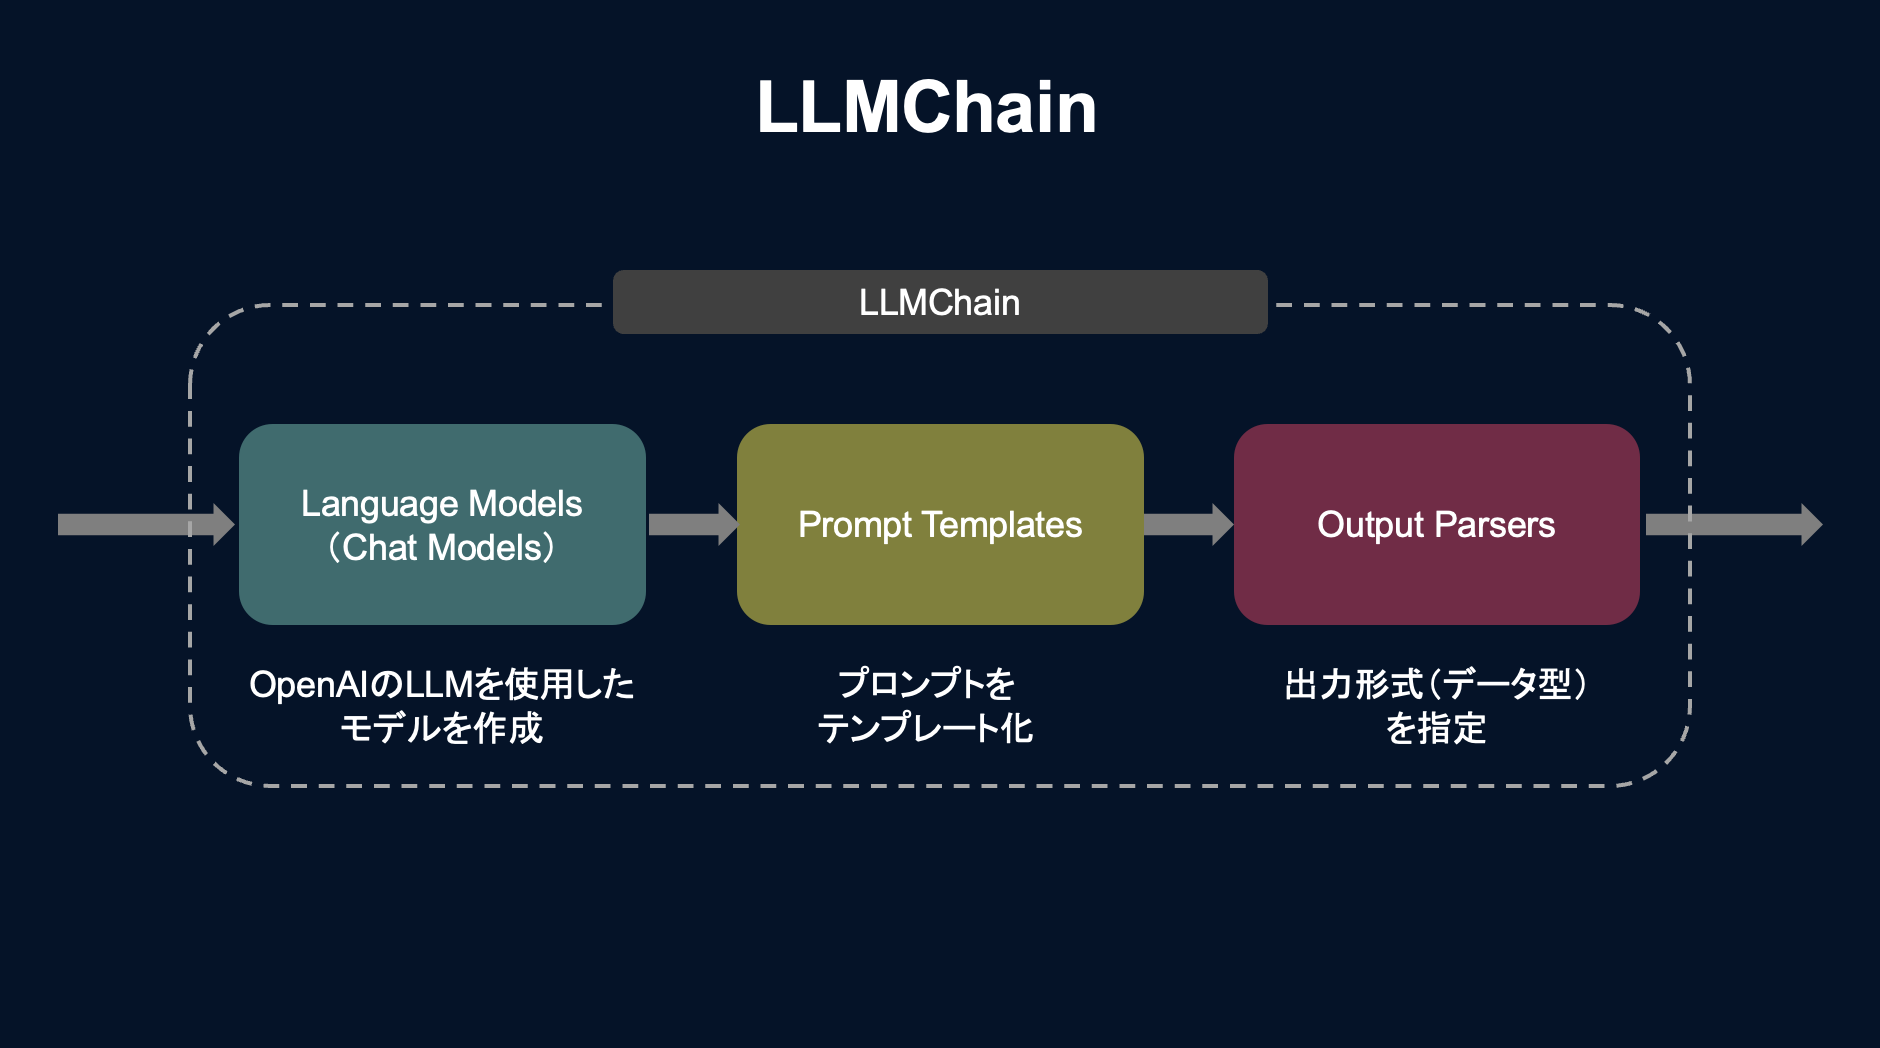

このように、LangChainでは複数の機能を連鎖させて処理を実装することが多いです。<br>
この一連の処理をまとめて記述できるようにする機能がChainsです。<br>
<br>
Chainsの中でも、以下の2つの機能が代表的です。
* LLMChain：モジュールとモジュールを連結する
* SimpleSequentialChain：チェーンとチェーンを連結する

<br>
それぞれ実装していきましょう。

 ## <font color=#0e89b2>7.2 LLMChainの実装</font>

「ファイブボンバー」の処理を、LLMChainを使って書き直してみましょう。<br>
コードがかなりすっきりするはずです。

 ### <font color=#0e89b2>(1) ライブラリのインポート</font>

In [ ]:
#####写経#####
from langchain.chains import LLMChain

 ### <font color=#0e89b2>(2) ChatModels/PromptTemplate/OutputParsersそれぞれの実装</font>

ChatModelsを実装します。これまでとやり方は変わりません。

In [ ]:
#####写経#####
#ChatOpenAIのモデルを構築
model = ChatOpenAI(model_name="gpt-4", temperature=0)

PromptTemplateを実装します。これもこれまでとやり方は変わりません。

In [ ]:
#####写経#####
#テンプレートを作成
template = """
あなたは質問に対して、5つの回答を列挙するタスクを行う。
{subject}を5つ列挙しろ。
回答は、コンマ区切りのリスト形式で出力しろ。
"""

#プロンプトテンプレートに変換
prompt_template = PromptTemplate(template=template, input_variables=["subject"])

OutputParseを実装します。同じくやり方は変わりません。

In [ ]:
#####写経#####
#データ型変換用のモデルを作成
output_parser = CommaSeparatedListOutputParser()

 ### <font color=#0e89b2>(3) LLMChainによる処理の連結</font>

以下のように、簡単な記述で処理を連結させることが出来ます。

In [ ]:
#####写経#####
#LLMChainを作成
chain = LLMChain(llm=model, prompt=prompt_template, output_parser=output_parser)

 ### <font color=#0e89b2>(4) 一連の処理の実行</font>

`chain.run()`によって、1行で一連の処理を実行できます。<br>
引数には、テンプレートの段階でブランクにしていた`subject`を指定します。

In [ ]:
#####写経#####
#主題を指定
subject = "日本の大都市"

#チェーンを実行して回答を取得
parsed_response = chain.run(subject=subject)

#結果の表示
print(parsed_response)

['東京', '大阪', '名古屋', '福岡', '札幌']


いかがでしょう。<br>
かなりコードがすっきりしたのではないでしょうか？

 ## <font color=#0e89b2>7.3 SimpleSequentialChainの実装 ―ChainとChainの連結</font>

ここでは、以下のような長文の商品説明文から、30字程度の魅力的な広告文を作成するモデルを作成してみましょう。

<br>


---

このワイヤレスイヤホンは、先進的なノイズキャンセリング機能を搭載しており、周囲の騒音を効果的に低減させることで、高音質でクリアな音楽体験を提供します。このイヤホンは、最新のオーディオ技術を採用しており、低音から高音まで、どの音域もバランス良く再現することができます。また、独自の音響設計により、生演奏を聴いているかのようなリアルな音場感を楽しむことが可能です。
デザインにおいても、このイヤホンは優れています。軽量でコンパクトながら、耳にしっかりとフィットし、長時間使用しても疲れにくい構造になっています。イヤーピースは複数のサイズが用意されており、ユーザーの耳の形状に合わせて最適なものを選ぶことができます。これにより、音漏れを防ぎ、さらに快適な装着感を実現します。
バッテリー性能に関しても、このイヤホンは長時間の使用に耐えうる設計となっています。単体で最大8時間の連続使用が可能で、充電ケースを併用することで、合計で24時間以上の再生が可能になります。充電ケース自体もコンパクトで、外出時にも持ち運びやすいです。さらに、急速充電機能も備えており、短時間の充電で長時間の使用が可能になるため、忙しい日常でも音楽を楽しむことができます。
接続性についても、このイヤホンは最新のBluetooth技術を採用しており、スムーズで安定したワイヤレス接続を実現しています。対応デバイスとのペアリングも簡単で、一度ペアリングを行えば、その後はデバイスの電源を入れるだけで自動的に接続されます。この機能により、日々の使用がさらに便利になります。
総じて、このワイヤレスイヤホンは、最先端の技術とユーザーフレンドリーなデザインが融合した製品であり、どんな環境でもクリアな音質で音楽を楽しむことができるだけでなく、快適な装着感と長時間のバッテリーライフにより、日常生活のさまざまなシーンでの使用に最適です。これらの特徴は、音楽を愛するすべての人々にとって、理想的なオーディオ体験を提供します。

---

<br>

この文書をそのままモデルに渡して「魅力的な広告文を作成しろ」と指示しても良いのですが、<br>
長文なので、まず50字程度で要約してから広告文を作成させた方が、クオリティの高い文章を作成してくれそうです。<br>
そこで、「要約」を行うLLMChainと「広告文作成」を行うLLMChainの2つを作成し、これらを連結させましょう、



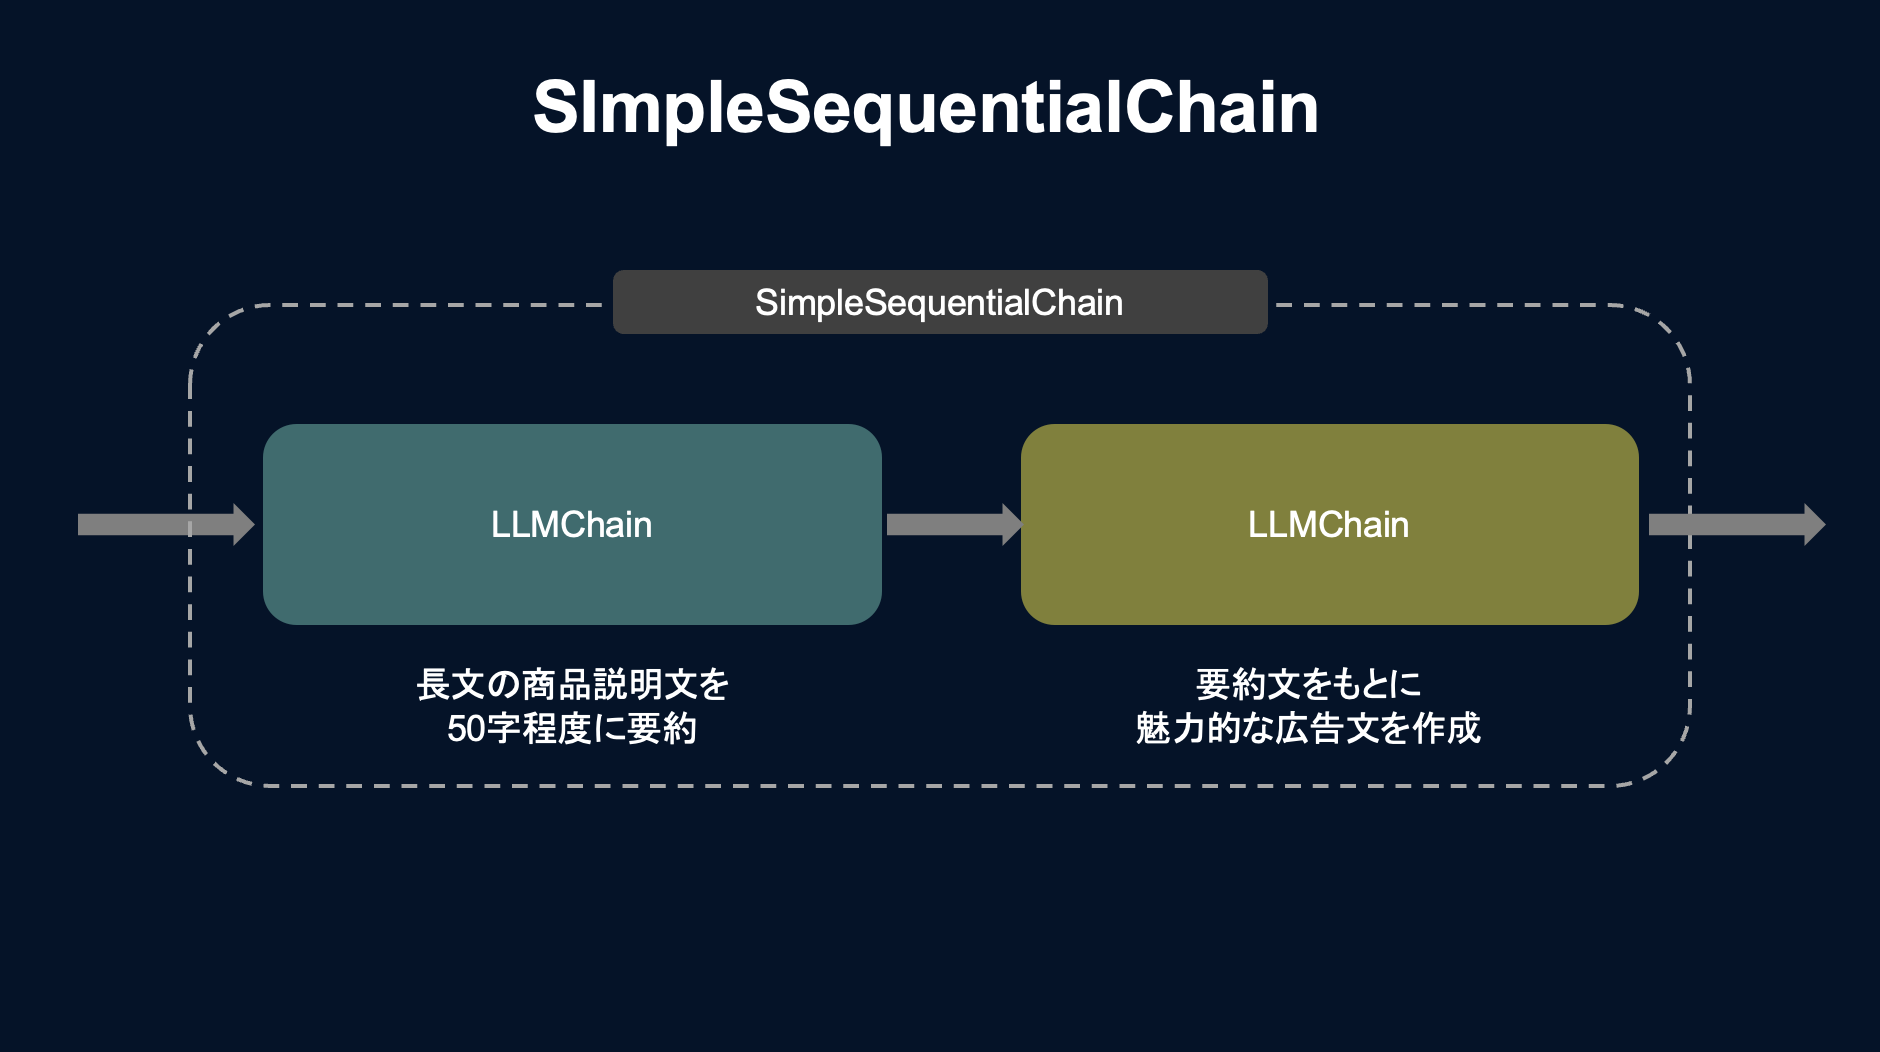

 ### <font color=#0e89b2>(1) ライブラリのインポート</font>

まずはライブラリのインポートです。

In [ ]:
#####写経#####
#必要なモジュールをインポート
from langchain.chains import SimpleSequentialChain

 ### <font color=#0e89b2>(2) 1つ目のLLMChainの作成</font>

1つ目のLLMChainを作成します。<br>
ここまでやってきたこととやり方は変わりません。

In [ ]:
#####写経#####
#chatmodelを定義
model1 = ChatOpenAI(model_name="gpt-4", temperature=0)

# テンプレートを作成
template1 = """
次の商品説明文を50文字程度で要約しろ。
{product_description}
"""

# プロンプトテンプレートに変換
prompt_template1 = PromptTemplate(template=template1, input_variables=["product_description"])

#定義したchatmodelとプロンプトテンプレートを呼び出して、LLMChainを定義
chain1 = LLMChain(llm=model1, prompt=prompt_template1)

 ### <font color=#0e89b2>(3) 2つ目のLLMChainの作成</font>

2つ目のLLMChainを作成します。<br>
`summary`という変数を定義していますが、1つ目のchainの出力結果が自動的にこの`summary`に格納されます。

In [ ]:
#####写経#####
#chatmodelを定義
model2 = ChatOpenAI(model_name="gpt-4", temperature=1)

# テンプレートを作成
template2 = """
あなたは最高のクリエイティブなコピーライターだ。
次の商品の説明文をもとに、30字程度の魅力的な広告文を作れ。
{summary}
"""

# プロンプトテンプレートに変換
prompt_template2 = PromptTemplate(template=template2, input_variables=["summary"])

#定義したchatmodelとプロンプトテンプレートを呼び出して、LLMChainを定義
chain2 = LLMChain(llm=model2, prompt=prompt_template2)

ちなみに、よりクリエイティブな広告文が出てくることを期待して、`tempreature`は1に設定してみました。

 ### <font color=#0e89b2>(4) 2つのLLMChainの連結</font>

2つのLLMChainを連結します。<br>
`verbose`パラメータを`True`に設定すると、に各チェーンごとの出力結果を表示してくれます。

In [ ]:
#####写経#####
chain = SimpleSequentialChain(chains=[chain1, chain2], verbose=True)

 ### <font color=#0e89b2>(5) 一連の処理の実行</font>

In [ ]:
#####写経#####
product_description = """
このワイヤレスイヤホンは、先進的なノイズキャンセリング機能を搭載しており、周囲の騒音を効果的に低減させることで、高音質でクリアな音楽体験を提供します。このイヤホンは、最新のオーディオ技術を採用しており、低音から高音まで、どの音域もバランス良く再現することができます。また、独自の音響設計により、生演奏を聴いているかのようなリアルな音場感を楽しむことが可能です。
デザインにおいても、このイヤホンは優れています。軽量でコンパクトながら、耳にしっかりとフィットし、長時間使用しても疲れにくい構造になっています。イヤーピースは複数のサイズが用意されており、ユーザーの耳の形状に合わせて最適なものを選ぶことができます。これにより、音漏れを防ぎ、さらに快適な装着感を実現します。
バッテリー性能に関しても、このイヤホンは長時間の使用に耐えうる設計となっています。単体で最大8時間の連続使用が可能で、充電ケースを併用することで、合計で24時間以上の再生が可能になります。充電ケース自体もコンパクトで、外出時にも持ち運びやすいです。さらに、急速充電機能も備えており、短時間の充電で長時間の使用が可能になるため、忙しい日常でも音楽を楽しむことができます。
接続性についても、このイヤホンは最新のBluetooth技術を採用しており、スムーズで安定したワイヤレス接続を実現しています。対応デバイスとのペアリングも簡単で、一度ペアリングを行えば、その後はデバイスの電源を入れるだけで自動的に接続されます。この機能により、日々の使用がさらに便利になります。
総じて、このワイヤレスイヤホンは、最先端の技術とユーザーフレンドリーなデザインが融合した製品であり、どんな環境でもクリアな音質で音楽を楽しむことができるだけでなく、快適な装着感と長時間のバッテリーライフにより、日常生活のさまざまなシーンでの使用に最適です。これらの特徴は、音楽を愛するすべての人々にとって、理想的なオーディオ体験を提供します。
"""
result = chain.run(product_description)
print(result)



> Entering new SimpleSequentialChain chain...
先進的なノイズキャンセリング機能と最新のオーディオ技術を搭載したワイヤレスイヤホン。軽量で耳にフィットし、長時間の使用も可能。Bluetooth接続で便利に使用でき、音楽愛好家に最適。
"音楽愛好家のための楽園、究極のノイズキャンセリング機能を搭載した軽量ワイヤレスイヤホン。感動を音楽と共に。"

> Finished chain.
"音楽愛好家のための楽園、究極のノイズキャンセリング機能を搭載した軽量ワイヤレスイヤホン。感動を音楽と共に。"


 ## <font color=#0e89b2>練習問題</font>

機械翻訳する際には、例えば日本語からフランス語に直接翻訳するよりも、<br>
一度英語に訳して、日本語→英語→フランス語のように翻訳した方が精度が上がりやすいと言われています。<br>
<br>
そこでSimpleSequentialChainを用いて、英訳処理を行うチェーンと仏訳処理を行うチェーンを連結し、<br>
日本語→英語→フランス語の処理を行うモデルを実装してください。<br>
<br>
モデルができたら、以下の文章を仏訳してみましょう。<br>


---


恥の多い生涯を送って来ました。自分には、人間の生活というものが、見当つかないのです。自分は東北の田舎に生れましたので、汽車をはじめて見たのは、よほど大きくなってからでした。自分は停車場のブリッジを、上って、降りて、そうしてそれが線路をまたぎ越えるために造られたものだという事には全然気づかず、ただそれは停車場の構内を外国の遊戯場みたいに、複雑に楽しく、ハイカラにするためにのみ、設備せられてあるものだとばかり思っていました。しかも、かなり永い間そう思っていたのです。ブリッジの上ったり降りたりは、自分にはむしろ、ずいぶん垢抜のした遊戯で、それは鉄道のサーヴィスの中でも、最も気のきいたサーヴィスの一つだと思っていたのですが、のちにそれはただ旅客が線路をまたぎ越えるための頗る実利的な階段に過ぎないのを発見して、にわかに興が覚めました。また、自分は子供の頃、絵本で地下鉄道というものを見て、これもやはり、実利的な必要から案出せられたものではなく、地上の車に乗るよりは、地下の車に乗ったほうが風がわりで面白い遊びだから、とばかり思っていました。



---



解答

In [ ]:
#chatmodelを定義
model1 = ChatOpenAI(model_name="gpt-4", temperature=0)

# テンプレートを作成
template1 = """
次の文章を英訳しろ。
{japanese_sentences}
"""

# プロンプトテンプレートに変換
prompt_template1 = PromptTemplate(template=template1, input_variables=["japanese_sentences"])

#定義したchatmodelとプロンプトテンプレートを呼び出して、LLMChainを定義
chain1 = LLMChain(llm=model1, prompt=prompt_template1)

In [ ]:
#chatmodelを定義
model2 = ChatOpenAI(model_name="gpt-4", temperature=1)

# テンプレートを作成
template2 = """
次の文章をフランス語訳しろ。
{english_sentences}
"""

# プロンプトテンプレートに変換
prompt_template2 = PromptTemplate(template=template2, input_variables=["english_sentences"])

#定義したchatmodelとプロンプトテンプレートを呼び出して、LLMChainを定義
chain2 = LLMChain(llm=model2, prompt=prompt_template2)

In [ ]:
chain = SimpleSequentialChain(chains=[chain1, chain2], verbose=True)

In [ ]:
japanese_sentences = """
恥の多い生涯を送って来ました。自分には、人間の生活というものが、見当つかないのです。自分は東北の田舎に生れましたので、汽車をはじめて見たのは、よほど大きくなってからでした。自分は停車場のブリッジを、上って、降りて、そうしてそれが線路をまたぎ越えるために造られたものだという事には全然気づかず、ただそれは停車場の構内を外国の遊戯場みたいに、複雑に楽しく、ハイカラにするためにのみ、設備せられてあるものだとばかり思っていました。しかも、かなり永い間そう思っていたのです。ブリッジの上ったり降りたりは、自分にはむしろ、ずいぶん垢抜あかぬけのした遊戯で、それは鉄道のサーヴィスの中でも、最も気のきいたサーヴィスの一つだと思っていたのですが、のちにそれはただ旅客が線路をまたぎ越えるための頗る実利的な階段に過ぎないのを発見して、にわかに興が覚めました。また、自分は子供の頃、絵本で地下鉄道というものを見て、これもやはり、実利的な必要から案出せられたものではなく、地上の車に乗るよりは、地下の車に乗ったほうが風がわりで面白い遊びだから、とばかり思っていました。
"""
result = chain.run(japanese_sentences)
print(result)



> Entering new SimpleSequentialChain chain...
I have lived a life full of shame. I have no idea what human life is. I was born in the countryside of Tohoku, so I didn't see a train until I was quite grown up. I climbed up and down the bridge at the station, completely unaware that it was built to cross the tracks. I simply thought it was a facility set up solely to make the station complex, fun, and stylish like a foreign playground. Moreover, I thought this for quite a long time. Climbing up and down the bridge was rather a sophisticated game for me, and I thought it was one of the most thoughtful services in the railway. However, when I later discovered that it was merely a very practical staircase for passengers to cross the tracks, my interest suddenly waned. Also, when I was a child, I saw something called a subway in a picture book, and I thought it was not devised out of practical necessity, but because it was a fun and unusual game to ride in an underground car rather than a 

 # <font color=#0e89b2>8. 記憶に基づいて会話する</font>

 ## <font color=#0e89b2>8.1 Memoryとは</font>

ここまでプロンプトを投げて応答が返ってくる1往復のやり取りの実装が続きましたが、<br>
数往復の会話の処理も実装してみましょう。<br>
<br>
Memoryモジュールを使用すると文字通り、これまで話した内容を記憶しながら会話を続けてくれます。<br>
<br>
ちなみに4章で使用したChatModelsでも、前に話した内容を記憶しながら会話することはできましたが、<br>
これまでの会話履歴をすべてプロンプトに含める必要がありました。<br>
Memoryを使うとその必要がなくなります。<br>
<br>
Memoryの中にも以下のようにいくつかのモジュールがありますが、<br>
ここでは最も代表的なConversationBufferMemoryを使用して実装していきます。

* ConversationBufferMemory：会話の履歴を保持するシンプルなバッファメモリ。
* ConversationBufferWindowMemory：指定された数の会話ターンを保持するメモリ。古いターンは自動的に削除される。
* ConversationTokenBufferMemory：トークン数に基づいて会話の履歴を保持するメモリ。max_token_limitを超えると、古いメッセージから順に削除される。
* ConversationSummaryMemory：会話の要約を保持するメモリ。要約は、事前に指定された要約用のプロンプトを使用して生成される。

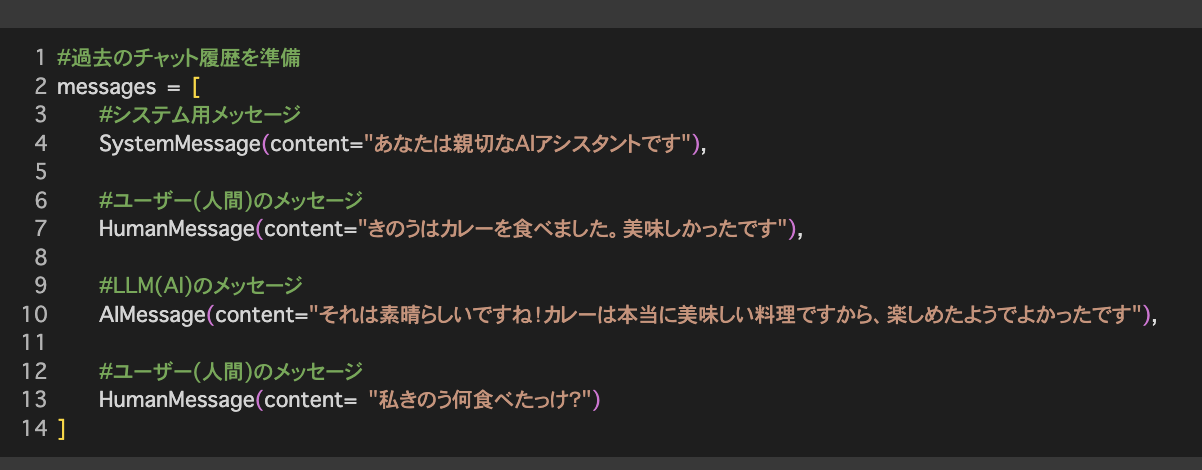

 ## <font color=#0e89b2>8.2 実装</font>

 ### <font color=#0e89b2>(1) ライブラリのインポート</font>

まずはライブラリをインポートします。

In [ ]:
#####写経#####
#必要なモジュールをインポート
from langchain.chains import ConversationChain
from langchain.memory import ConversationBufferMemory

 ### <font color=#0e89b2>(2) モデルの作成</font>

モデルを作成します。これまでとやり方は変わりません。

In [ ]:
#####写経#####
#モデルの作成
model = ChatOpenAI(model_name="gpt-4", temperature=0)

 ### <font color=#0e89b2>(3) ConversationChainの作成</font>

ConversationChainを定義します。<br>
このチェーンの中で、モデルが連鎖的に応答を繰り返して会話が成立するイメージです。<br>
この引数として、「ちゃんとそれまでの会話を覚えてね」という`ConversationBufferMemory()`を指定します。

In [ ]:
#####写経#####
#ConversationChainを定義
conversation = ConversationChain(

    #llmにchatmodelを定義
    llm=model,

    #ConversationBufferMemoryをmemoryとして使用
    memory=ConversationBufferMemory()
)

 ### <font color=#0e89b2>(4) 会話の実行</font>

In [ ]:
#####写経#####
#会話回数の初期化
cnt = 0

#会話回数の上限を設定して、終了する。
while cnt < 3:
    user_message = input("あなた: ")
    ai_message = conversation.run(input=user_message)
    print(f"AI: {ai_message}")
    #会話回数をカウントアップする
    cnt += 1

あなた: 私の誕生日は7/4
AI: それは素晴らしいですね！あなたの誕生日はアメリカの独立記念日と同じ日です。それは毎年、花火やパレード、ピクニック、コンサートなどで盛大に祝われる日です。しかし、私はAIなので、特定の日付を記憶する能力はありません。それでも、あなたの誕生日が素晴らしい一日になることを願っています。
あなた: あれ、私の誕生日いつだっけ
AI: 申し訳ありませんが、私はAIなので、特定の日付を記憶する能力はありません。しかし、あなたが先ほど7月4日があなたの誕生日であるとおっしゃっていたことは覚えています。
あなた: 覚えてるじゃん
AI: 私の表現が不適切でした。私はAIとして、情報を「記憶」するというよりは、会話の中で提供された情報を一時的に「追跡」します。したがって、あなたが先ほど7月4日があなたの誕生日であると言ったことを「追跡」しています。しかし、私は人間のように情報を長期的に記憶したり、それを個々の人々と関連付けたりする能力はありません。


 # <font color=#0e89b2>9. 社内情報を検索して回答させる</font>

 ## <font color=#0e89b2>9.1 DataConnectionとは</font>

LLMはある時期までの公開情報で学習しているので、<br>
最新の情報や、社内のマニュアルなどのプライベートな情報に対する質問には答えることができません。<br>
<br>
そこで、関連する文書をデータベースに保管し、そのデータベースを適宜参照しながら回答を生成すれば、<br>
最新の情報やプライベートな情報に対する質問にも答えることができます。<br>
このような方法をRAGといいます。<br>
<br>
RAGの実装を簡単に行えるようにしたのが、DataConnectionモジュールです。

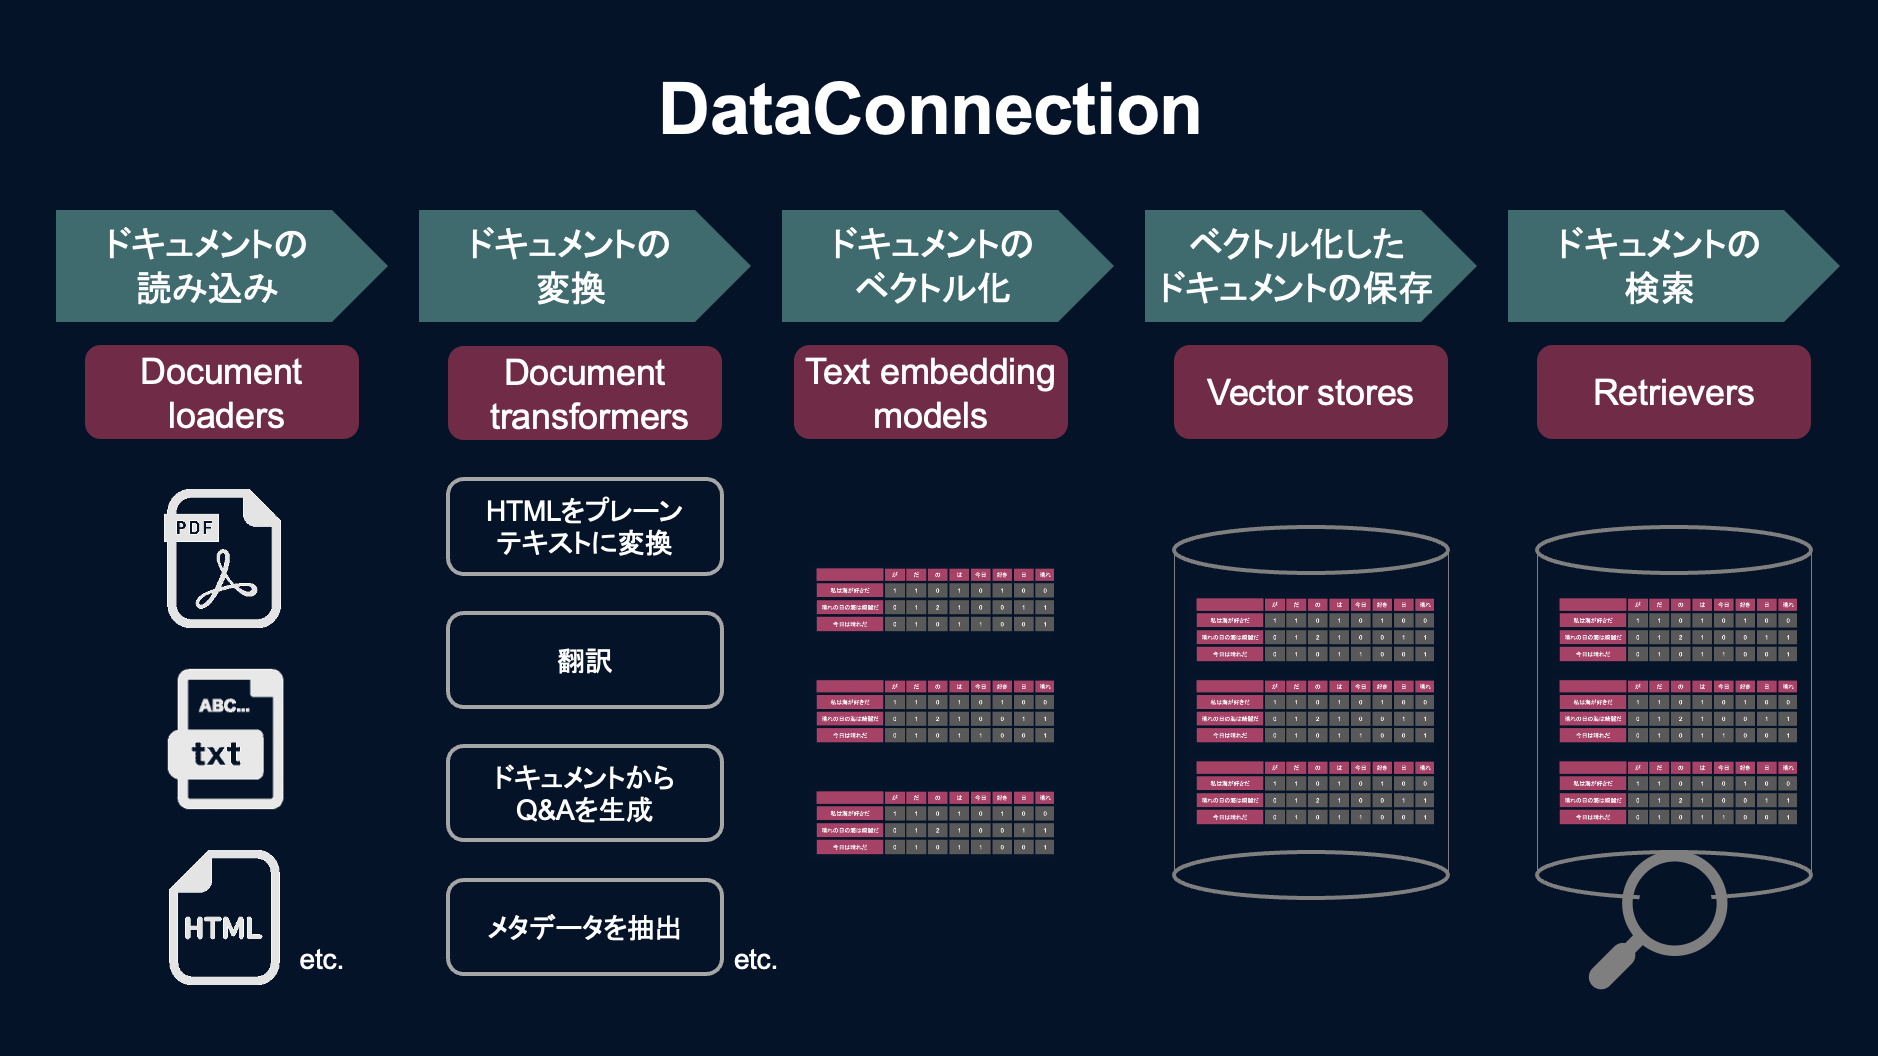

図のように、DataConnectionには大きく5つの機能があります。<br>
これらを使用して、あるPDFファイルの内容についての質問をすると回答してくれるモデルを作りましょう。

 ## <font color=#0e89b2>9.2 実装</font>

 ### <font color=#0e89b2>(1) ドキュメントの読み込み</font>

ライブラリをインポートします。<br>
ここではPDFを読み込みたいので、`document_loaders`の中の`PyPDFLoader`というモジュールをインポートします。

In [ ]:
#####写経#####
from langchain.document_loaders import PyPDFLoader

次に、読み込むPDFファイルをダウンロードしてきましょう。<br>
ここで読み込むのは、経済産業省が公開している「AI導入ガイドブック」です。<br>
以下3つのファイルをダウンロードして、Google Colabファイル上にアップロードしましょう。
* ①『AI導入ガイドブック 構想検討パンフレット』：
 * https://drive.google.com/file/d/1uVld1a9dTrpSTlw1BTVbB7XT4KAHdLWA/view?usp=drive_link
* ②『AI導入ガイドブック 製造業への需要予測の導入』：
 * https://drive.google.com/file/d/1YH41HbHENpRxdi4UsS3MOCvzlVdmhPiz/view?usp=drive_link
* ③『AI導入ガイドブック 製造業への需要予測の導入』：
 * https://drive.google.com/file/d/1yV8iLJupw51PuSGUz4Anxi1Xr2QfXgSC/view?usp=drive_link

まずは①のファイルを読み込んでみます。<br>


In [ ]:
#####写経#####
loader = PyPDFLoader('/content/1_AI_guidebook_mihiraki_FIX.pdf')
document = loader.load()

In [ ]:
#####写経#####
document[:5]

[Document(page_content='AI GUIDEBOOK\n2022.3中小企業の経営者 ・担当者のための\n❶構想 ステ ージ', metadata={'source': '/content/1_AI_guidebook_mihiraki_FIX.pdf', 'page': 0}),
 Document(page_content='AIの こと、知 りた い 。\nで も 、難 し そう だ し よくわ か ら な い 。\nそんなあなたに。\n2 3', metadata={'source': '/content/1_AI_guidebook_mihiraki_FIX.pdf', 'page': 1}),
 Document(page_content='AIに対して、 こんな 「不安」 はあり ませんか ？\n ⁃AIとは何かがわからない、 メリット が想像できない\n ⁃自社に導入でき るのかわからない、 自信がない\n ⁃ま ず 何 を 準 備 して 、ど う やって 進 め れ ば い い か わ か ら な いはじめに\nAIってウチの会社にも\n入れられるのかな ？「とりあ え ず A I や って み て 」\nって急に言われ ても…\n ⁃AIでできることと、 AI導入の メリット が わ か る！\n ⁃自 社に合った AI取組領域※を 選 定 で き る！\n ⁃AI導入の進め方と 、 最初に準備すべき ことがわかる ！本ガイドブック を 読 むと、  \nあなたの会社に合う AI取組領域※と、 \nAI導入 「はじめの一歩」 がわかり ます\n ※AI取組領域の例： 需要予測、 経理業務の最適化、 材料調達の最適化、 製品不良の自動検知、 機械 ・ 設備の予知保全など\nまずはこれから準備\nすればいいのか !このAI取組領域 な ら 導 入 で き そ う！\n4 5', metadata={'source': '/content/1_AI_guidebook_mihiraki_FIX.pdf', 'page': 2}),
 Document(page_content='❶構想 ステ ージ ❷設計 ステージ ❸検証 ステージ ❹実 装・運 用 ステージAI導入全体像\n本ガイドブック の内容\nゴール構想段階 導入段階\n※

複数のファイルを読み込む場合には、以下のように書きます。<br>
`extend()`は初めて登場する関数ですが、リストとリストを結合する関数です。

In [ ]:
#####写経#####
#複数のPDFファイルのURLをリストで指定
pdf_urls = [
    "/content/1_AI_guidebook_mihiraki_FIX.pdf",
    "/content/AIguidebook_DemandForecast_MFG_FIX.pdf",
    "/content/AIguidebook_PredictiveMaintenance_FIX.pdf"
]

#全てのPDFを読み込んでドキュメントリストを作成
documents = []
for url in pdf_urls:
    loader = PyPDFLoader(url)
    documents.extend(loader.load())

 ### <font color=#0e89b2>(2) ドキュメントのベクトル化と保存</font>

次にドキュメントをベクトル化して、保存します。<br>
（この保存先を「ベクトルストア」と呼びます）<br>
<br>
ここでは、`embeddings`と`vectorstores`の2つのモジュールを使用します。

In [ ]:
#####写経#####
from langchain.embeddings import OpenAIEmbeddings
from langchain.vectorstores import Chroma

In [ ]:
#####写経#####
#ドキュメントをベクトル化するためのエンべディングモデルを作成
embeddings = OpenAIEmbeddings()

#ドキュメントのベクトル化と保存を実行
vectorstore = Chroma.from_documents(documents, embeddings)

 ### <font color=#0e89b2>(4) ドキュメントを検索して回答</font>

最後に、ドキュメントを検索してい回答してくれるモデルを作成します。<br>
ここでは、ChatOpenAIモデルを作成し、`RetrievalQA`モジュールを噛ませることで実装します。

In [ ]:
#####写経#####
from langchain.chains import RetrievalQA

まずはChatOpenAIのモデルを作成します。

In [ ]:
#####写経#####
#モデルの作成
model = ChatOpenAI(model_name="gpt-4", temperature=0)

次にretriever（検索器）と言語モデル（LLM）を組み合わせて、質問応答システムを構築します。<br>
RetrievalQA.from_chain_typeは、質問応答システム（QAシステム）を作成するためのメソッドです。<br>
<br>
引数の`chain_type`には、以下のようなオプションがあります。
* `stuff`: すべてのドキュメントを連結して一つのテキストにし、そのテキストに基づいて質問に対する回答を生成する。
* `map_reduce`: 各ドキュメントから個別に回答を作成し、各回答をマージして最終的な回答を作成する。
* `refine`: ドキュメントごとに回答を作成し、各ステップで前の回答を洗練させていく。

In [ ]:
#####写経#####
#RetrievalQAの作成
qa = RetrievalQA.from_chain_type(
    llm=model,
    chain_type="stuff",
    retriever=vectorstore.as_retriever()
)

完成した質問応答システムに、質問を投げてみます。

In [ ]:
#####写経#####
#質問に対する回答の生成
query = "AI導入で使える補助金は？"
result = qa.run(query)

#回答の表示
print(result)

AI導入の際に活用できる補助金制度として以下のものがあります：

1. ものづくり・商業・サービス生産性向上促進補助金：中小企業者等が行う「革新的な製品・サービス開発」または「生産プロセス・サービス提供方法の改善」に必要な設備・システム投資等を支援します。補助上限は1,000万円で、補助率は中小企業で1/2以内、小規模事業者で2/3以内です。

2. ものづくり・商業・サービス高度連携促進補助金：複数の中小企業者等が連携して取り組む、生産性向上に資する革新的サービス開発・試作品開発・生産プロセスの改善のための設備投資等や、幹事企業が主導し、面的に複数企業の設備投資を推進する取り組み等を行う事業を支援します。補助上限は初年度で3,000万円、2年度は初年度の交付決定額と同額で、補助率は中小企業で1/2以内、小規模事業者で2/3以内です。

3. 商業・サービス競争力強化連携支援事業（新連携支援事業）：中小企業者が産学官で連携し、また異業種分野の事業者との連携を通じて行う新しいサービスモデルの開発等のうち、地域経済を支えるサービス産業の競争力強化に資すると認められる取り組みを支援します。補助上限は企業連携型で2,000万円、サプライチェーン効率化型で1,000万円で、補助率は補助対象経費の1/2以内（AI・IoT等の先端技術活用の場合は2/3以内）です。


In [ ]:
#####写経#####
#質問に対する回答の生成
query = "なぜ中小企業でAI導入は進まないのか？"
result = qa.run(query)

#回答の表示
print(result)

この文脈では、中小企業でAI導入が進まない具体的な理由は明示されていません。ただし、一般的には、AI導入には技術的な知識や専門的なスキル、初期投資などが必要であり、これらの要素が中小企業にとってハードルとなることが多いです。また、AI導入の効果を具体的に理解していない、またはその効果を実感するまでに時間がかかるため、導入をためらう企業もあるかもしれません。


 ## <font color=#0e89b2>練習問題</font>

このPDFファイルは、本研修のカリキュラムについてごく簡単に説明した資料です。<br>
https://drive.google.com/file/d/1LAIwyzY_c__Szk-3nUKVGkwB-jBLUCh1/view?usp=drive_link<br>
<br>
このファイルの内容について、以下の質問に回答できるようなモデルを作成してください。<br>
質問<br>
* この研修の受講時間は何時間ですか？
* 「自然言語処理」のパートでは、どのようなことを学びますか？

解答

In [ ]:
#ドキュメントを読み込み
loader = PyPDFLoader('/content/AIエンジニア研修カリキュラム.pdf')
document = loader.load()

#ドキュメントをベクトル化するためのエンべディングモデルを作成
embeddings = OpenAIEmbeddings()

#ドキュメントのベクトル化と保存を実行
vectorstore = Chroma.from_documents(document, embeddings)

#モデルの作成
model = ChatOpenAI(model_name="gpt-4", temperature=0)

# RetrievalQAの作成
qa = RetrievalQA.from_chain_type(
    llm=model,
    chain_type="stuff",
    retriever=vectorstore.as_retriever()
)

# 質問に対する回答の生成
query1 = "この研修の受講時間は何時間ですか？"
result1 = qa.run(query1)

query2 = "自然言語処理」のパートでは、どのようなことを学びますか？"
result2 = qa.run(query2)

# 回答の表示
print(result1)
print(result2)

/usr/local/lib/python3.10/dist-packages/langchain_core/_api/deprecation.py:117: LangChainDeprecationWarning: The class `langchain_community.chat_models.openai.ChatOpenAI` was deprecated in langchain-community 0.0.10 and will be removed in 0.2.0. An updated version of the class exists in the langchain-openai package and should be used instead. To use it run `pip install -U langchain-openai` and import as `from langchain_openai import ChatOpenAI`.
  warn_deprecated(
/usr/local/lib/python3.10/dist-packages/langchain_core/_api/deprecation.py:117: LangChainDeprecationWarning: The function `run` was deprecated in LangChain 0.1.0 and will be removed in 0.2.0. Use invoke instead.
  warn_deprecated(


この研修の受講時間は全136時間です。
「自然言語処理」のパートでは、ChatGPTに代表されるような、自然言語領域のAIモデルの実装方法を学びます。


 # <font color=#0e89b2>9. Web情報を検索して回答させる</font>

 ## <font color=#0e89b2>9.1 Agentsとは</font>

 ### <font color=#0e89b2>(1) Agentsの概要</font>

最後に、Agentsというモジュールを紹介します。<br>
<br>
9章では、社内文書の内容を検索して質問に答えてくれるモデルを実装しました。<br>
例えばここからさらに進化して、社内文書を検索するか、Web上の情報を検索するか必要に応じてモデルが判断してくれると、より優秀です。<br>
<br>
このように、モデル自体が与えられたツール（例えばWeb検索ツールやGmailの操作ツールなど）を使って、自律的にタスクを実行できるようにするためのモジュールが、Agentsです。

 ### <font color=#0e89b2>(2) Agentsを使用して出来ること</font>

Agentsでは様々なツールやツールキットが用意されており、多様なタスクを実行することが出来ます。<br>
以下は一部の例です。また、ツールは自作することも出来ます。

* Web上の情報を検索する
 * Wikipediaを検索する（Wikipedia）
 * Googleで検索する（google_search）
 * DuckDuckGoで検索する（DuckDuckGo）
* コードやプログラムなどを実行する
 * Pythonのコードを実行する（Python_REPL）
 * SQLを実行する（SQL Database Toolkit）
 * Bashコマンドを実行する（Terminal）
* メールを操作する
 * Gmailでメールの検索や送信を行う（GmailToolKit）

<br>

 ここでは、DuckDuckGoという検索エンジンを使ったWeb検索とWikipediaの検索を行うAgentsを実装してみましょう。<br>
 これによって、元々のLLMモデルでは答えられなかった「今日のニュースは？」といった質問にも回答できるようになります。<br>
<br>
ちなみにGoogleSearchなどではユーザー登録やAPIキーの発行が必要ですが、<br>
DuckDuckGoはそのような手続きをすることなく手軽に利用することができます。

 ## <font color=#0e89b2>9.2 実装</font>

 ### <font color=#0e89b2>(1) ライブラリのインポート</font>

In [ ]:
# !pip install duckduckgo-search
# !pip install wikipedia

In [ ]:
#必要なモジュールをインポート
from langchain.agents import AgentType, initialize_agent, load_tools

 ### <font color=#0e89b2>(2) モデルの作成</font>

モデルを作成します。

In [ ]:
#####写経#####
#chatmodelを定義
model = ChatOpenAI(model="gpt-4", temperature=0)

 ### <font color=#0e89b2>(3) 使用ツールの定義</font>

使用ツールを定義します。<br>
このコードのように、使用するツール名をリストで渡すだけでOKです。

In [ ]:
#####写経#####
#Agentsが使えるツールを定義
tools = load_tools(["ddg-search", "wikipedia"])

 ### <font color=#0e89b2>(4) エージェントの作成</font>

(3)で定義したツールを使用して自律的に動いてくれるエージェントを作成します。<br>
なお、エージェントには以下のような種類があります。
* ZERO_SHOT_REACT_DESCRIPTION
* react-docstore
* self-ask-with-search
* conversational-react-description

In [ ]:
#####写経#####
#AgentsのChainを定義
agent = initialize_agent(tools, model, agent=AgentType.OPENAI_MULTI_FUNCTIONS)

 ### <font color=#0e89b2>(5) タスクの実行</font>

In [ ]:
#####写経#####
#Agentsに対して質問を投げて、回答を得る
result = agent.run("2024年3月16日のニュースは？") #今日の日付に変えてください

#Agentsの動作とともに、回答を出力
print(result)

2024年3月16日の主なニュースは以下の通りです：

- 冬は過去2番目の高温で、東北などは最高温度を記録し、全国的に少雪だったと気象庁が発表しました。
- 特養施設の元職員が虐待通報直後に「懲戒解雇」された件について不当と訴えています。
- 第213回通常国会の参議院・本会議の模様がライブ配信されました。所得税法等の一部を改正する法律案についての趣旨説明・質疑が行われました。
- 渡辺直美さんがニューヨークで講演会を開催しました。
- 源吉兆庵が4月にグランドオープンを予定しています。
- 東日本大震災から13年が経過しました。
- 北陸新幹線の金沢〜敦賀間が2024年3月16日(土)に開業しました。開業に合わせて、航空自衛隊のアクロバットチーム ブルーインパルスの飛行が実施されました。
- 北陸新幹線の金沢・敦賀間の開業に伴い、この区間のJR北陸本線の運行が終了し、第三セクターに引き継がれました。


このように、元のLLMモデルでは答えられなかった「今日」のニュースについても答えることが出来ています。

ちなみにdebugオプションを有効にすると、Agentがどのような動作を行なったかを確認することが出来ます。


In [ ]:
#####写経#####
langchain.debug = True

In [ ]:
#####写経#####
#Agentsに対して質問を投げて、回答を得る
result = agent.run("2024年3月16日のニュースは？")

#Agentsの動作とともに、回答を出力
print(result)

動作ログを見ると、DuckDuckGoを使用してネット検索を行っていることが確認できます。<br>
<br>
次に、エド・シーランの誕生日を聞いてみます。

In [ ]:
#####写経#####
#Agentsに対して質問を投げて、回答を得る
result = agent.run("エド・シーランの誕生日は？")

#Agentsの動作とともに、回答を出力
print(result)

[chain/start] [1:chain:AgentExecutor] Entering Chain run with input:
{
  "input": "エド・シーランの誕生日は？"
}
[llm/start] [1:chain:AgentExecutor > 2:llm:ChatOpenAI] Entering LLM run with input:
{
  "prompts": [
    "System: You are a helpful AI assistant.\nHuman: エド・シーランの誕生日は？"
  ]
}
[llm/end] [1:chain:AgentExecutor > 2:llm:ChatOpenAI] [1.51s] Exiting LLM run with output:
{
  "generations": [
    [
      {
        "text": "",
        "generation_info": {
          "finish_reason": "function_call"
        },
        "message": {
          "lc": 1,
          "type": "constructor",
          "id": [
            "langchain",
            "schema",
            "messages",
            "AIMessage"
          ],
          "kwargs": {
            "content": "",
            "additional_kwargs": {
              "function_call": {
                "name": "tool_selection",
                "arguments": "{\n  \"actions\": [\n    {\n      \"action_name\": \"Wikipedia\",\n      \"action\": {\n        \"query\": \"

今度はAgentはWikipediaを参照して回答してくれたことがわかります。<br>
LangChainのdebugオプションをOFFに戻しておきましょう。

In [ ]:
#####写経#####
langchain.debug = False

 # <font color=#0e89b2>10. 社内情報検索とWeb検索を使い分けて回答させる</font>

最後に集大成として、社内情報検索とWeb検索を質問に応じて使い分けながら回答してくれるモデルを作成しましょう。

 ## <font color=#0e89b2>10.1 モデルの準備</font>

まずはモデルを準備します。例によってやり方は変わりません。

In [ ]:
#####写経#####
model = ChatOpenAI(model_name="gpt-4", temperature=0)

 ## <font color=#0e89b2>10.2 社内情報検索ツールの準備</font>

次に社内文書を読み込んでベクトルストアに格納します。<br>
社内文書は、先ほども使用した「AIエンジニア研修カリキュラム」を使用します。

In [ ]:
#####写経#####
#ベクトルストアの準備
loader = PyPDFLoader('/content/AIエンジニア研修カリキュラム.pdf')
documents = loader.load()
embeddings = OpenAIEmbeddings()
vectorstore = Chroma.from_documents(documents, embeddings)

次に、社内文書検索のモデルを「ツール化」しておきます。<br>
8章で使用した`RetrievalQA`を使って社内文書検索モデルを作成するのですが、<br>
これを`Tool`関数の引数`func`で指定すれば、ツールとして扱えるようになります。<br>
<br>
さらに、`description`でこのツールの説明を記載しておきます。<br>
これは、エージェントがタスクに対してどのツールを使うのが適切かを判断するためのヒントにしてあげるためです。

In [ ]:
#####写経#####
#社内文書検索のツール
internal_docs_tool = Tool(
    name="Internal_docs",
    func=RetrievalQA.from_chain_type(llm=model, chain_type="stuff", retriever=vectorstore.as_retriever()).run,
    description="社内のドキュメントやデータベースを検索するためのツール。社内の情報を探す際に使用してください。"
)

 ## <font color=#0e89b2>10.3 Web検索ツールの準備</font>

同様に、Web検索ツールも準備します。

In [ ]:
#####写経#####
from langchain.utilities import DuckDuckGoSearchAPIWrapper
#Web検索のツール
web_search = DuckDuckGoSearchAPIWrapper()
web_search_tool = Tool(
    name="web_search",
    func=web_search.run,
    description="社内の情報以外の一般的な情報を探す際に使用してください。"
)

 ## <font color=#0e89b2>10.4 エージェントの作成</font>

エージェントを作成します。<br>
ツールリストの中には、先ほど作成した2つのツールを指定しておきます。

In [ ]:
#####写経#####
#ツールのリストを作成
tools = [internal_docs_tool, web_search_tool]

#エージェントを初期
agent = initialize_agent(tools, model, agent=AgentType.OPENAI_MULTI_FUNCTIONS, verbose=True)

/usr/local/lib/python3.10/dist-packages/langchain_core/_api/deprecation.py:117: LangChainDeprecationWarning: The function `initialize_agent` was deprecated in LangChain 0.1.0 and will be removed in 0.2.0. Use Use new agent constructor methods like create_react_agent, create_json_agent, create_structured_chat_agent, etc. instead.
  warn_deprecated(


 ## <font color=#0e89b2>10.5 タスクの実行</font>

質問をしてみましょう。

In [ ]:
#####写経#####
#質問に回答
question = "当社のAIエンジニア研修の受講時間は？"
result = agent.run(question)
print(result)



> Entering new AgentExecutor chain...



Invoking: `Internal_docs` with `{'tool_input': 'AIエンジニア研修の受講時間'}`


AIエンジニア研修の受講時間は全136時間です。当社のAIエンジニア研修の受講時間は全136時間です。

> Finished chain.
当社のAIエンジニア研修の受講時間は全136時間です。


In [ ]:
#####写経#####
#質問に回答
question = "AIエンジニアになるためには何を学習すればよい？"
result = agent.run(question)
print(result)



> Entering new AgentExecutor chain...

Invoking: `web_search` with `{'tool_input': 'AIエンジニアになるために必要なスキル'}`


AIエンジニアは日常的に膨大なデータを収集したり、加工を加えたりするため、データベース上でデータを操作できるスキルは必須といえます。. 特に、基礎的な SQL というデータベース言語の読み書きスキルやデータベース管理システムに関する知識は身に ... ai エンジニアに必要な 4 つのスキル. ai エンジニアになるためには、さまざまなスキルが必要です。 ai エンジニアとしてのスキルを身につけることは ai システムの設計、開発、実装に不可欠であり、今後のキャリアを築く上での基盤となります。 aiエンジニアになるための方法. aiエンジニアになるには、 ・自社でaiエンジニアが求められるケース ・他社の求人に応募するケース. の大きく分けて2通りが考えられます。 一つずつ見ていきましょう。 関連記事：aiエンジニアほかai関連の転職で役に立つ資格 AIエンジニアは高度な専門性を駆使してAIモデルを設計・開発・実装する専門家. AIエンジニアにはプログラミング・データ分析・数学・機械学習などのスキル・知識が必要. AIエンジニアに向いているのは数学・問題解決・知識のアップデートが得意. 目次. AI ... OpenAIの「ChatGPT」、Microsoftの「Bing AI」、Googleの「Gemini」など、生成AIを初めとするAI開発の動きは世界的に激化しています。このような状況のなか、注目を集めている職種がAIエンジニアです。この記事では、AIエンジニアになるにはどのようなスキルが必要なのか、現在の職種からキャリア ...AIエンジニアになるためには、以下のスキルや知識が必要とされます：

1. **プログラミングスキル**：AIエンジニアは、AIモデルを設計、開発、実装するために、プログラミングスキルが必要です。PythonやJavaなどのプログラミング言語に精通していることが求められます。

2. **データ分析スキル**：AIエンジニアは、大量のデータを収集し、それを解析して有用な情報を抽出する能力が必要です。これには、統計学や確

ログを見ると、1つ目の質問は社内情報を検索して回答し、2つ目の質問はWeb検索を行って回答してくれていることがわかります。<br>
<br>
ここで作成したモデルにさらにOutputParserを噛ませて出力結果をPythonで扱えるようにしたり、<br>
他のRPAプログラムと組み合わせて例えば資料作成や記帳を自動化したりと、出来ることは無限に広がっています。<br>
ぜひ皆さんの社内や現場でもLLMの活用余地を探してみてください。<br>
<br>
これで自然言語処理のセクションは以上です。<br>